In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/insurance/insurance.csv


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/insurance


# Overall Objectives
> What this project aims to achieve

This project was created as a submission for Theme 5 of the Nissan Summer Internship. Using the Medical Cost Personal Dataset from Kaggle, the goal is to predict individual medical expenses using machine learning regression methods (the specific types are not restricted). Additionally, the project aims to evaluate model performance based on various metrics and to reflect on the results.

Predicting medical expenses based on information such as a patient’s age, gender, region, and smoking status can be useful from a business perspective. For example, if smoking significantly increases medical costs, insurance companies might consider charging higher premiums to smokers. This can lead to valuable insights and business strategies.

In this project, the following points will be emphasized:

1. Evaluation of each model using MAE, RMSE, and R² metrics

    - Why is it important to evaluate models using multiple types of metrics?

2. Reasons for selecting specific regression methods

    - Brief explanation of each model (Linear Regression, Random Forest, XGBoost, LightGBM)
  
---
# プロジェクトの目標
> このプロジェクトで何がしたいのか


このプロジェクトは、日産のサマーインターンシップ「テーマ5」への提出を目的として作成されました。KaggleのMedical Cost Personal Datasetを活用し、機械学習による回帰手法（種類の指定なし）を用いて、個人の医療費を予測します。また、さまざまな指標を基にモデルの性能を評価し、その結果を考察することも目的としています。

患者の年齢、性別、地域、喫煙の有無などの情報をもとに医療費を予測することは、ビジネス的な観点から有用です。例えば、喫煙が医療費の増加に影響を与えるとすれば、保険会社が喫煙者に対してより高い保険料を設定するなど、さまざまなインサイトやビジネス戦略を導くことが可能になります。

本プロジェクトでは、以下の点に重点を置いて説明します：

1. MAE、RMSE、R²の評価指標を用いた各モデルの性能評価

    - なぜ複数の指標を用いてモデルを評価することが重要なのか？

2. 回帰手法の選定理由

    - 各モデルの簡単な説明（Linear Regression、Random Forest、XGBoost、LightGBM）

# Index

1. EDA
    - 1-1. Data Cleaning
    - 1-2. Statistics
    - 1-3. Data visualization 
2. Model Training and Evaluation
    - 2-1. Import Libraries
    - 2-2. Load data and split into Train/Test set
    - 2-3. Data Engineering
    - 2-4. Model training and Evaluation
    - 2-5. Hyperparameter Optimization for LightGBM
    - 2-6. Stacking
3. Summary
    - 3-1. Overall Results and Visualization
    - 3-2. Final Predictions vs Real Value Scatter

# 1. EDA

In [3]:
df = pd.read_csv('/kaggle/input/insurance/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1-1. Cleaning the Data

The dataset consists of 7 columns, with the target variable being charges, representing the medical expenses. As a first step in the analysis, we will inspect the dataset for any missing values and examine the data types of each column to understand the overall structure.

--- 

このデータセットは7つの列で構成されており、予測すべきターゲット変数は「charges」、すなわち医療費です。分析の最初のステップとして、欠損値の有無と各列のデータ型を確認し、データの基本構造を把握します。

In [4]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Fortunately, there are no missing values in the dataset.

Based on our inspection, age, bmi, and children are numerical variables, while sex, smoker, and region are categorical.

Before training the model, we need to consider an appropriate preprocessing strategy. We will explore this in more detail in the preprocessing section. For now, let’s focus on exploring relationships between the variables to better understand the structure of the data.

---

幸いにも、このデータセットには欠損値が存在しません。

データ型の確認結果、age、bmi、children は数値型、sex、smoker、region はカテゴリ型であることが分かりました。

モデルの学習に入る前に、適切な前処理手法を検討する必要があります。前処理の詳細については後のセクションで扱う予定です。まずは各変数間の関係性を把握し、データの構造を理解することに集中します。

## 1-2. Statistics

In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Examining the distribution of the age variable, the youngest individual is 14 years old and the oldest is 64, with an average age of approximately 39.

For BMI, the average value is 30, with the lowest observed at 15 and the highest at 53.

Regarding the children variable, individuals typically have one child on average.

Next, we will visualize the distribution of these variables to gain a more intuitive understanding of the dataset.

---

まず、age（年齢）の分布を確認すると、最も若いサンプルは14歳、最年長は64歳であり、平均年齢は約39歳です。

BMI（体格指数）は平均30で、最小値は15、最大値は53となっています。

children（子供の数）に関しては、平均して1人の子供がいるサンプルが多いことが分かります。

これらの変数の分布を視覚化して、データの特徴をより直感的に理解しやすくします。


## 1-3. Data Visualization

In [7]:
from matplotlib import pyplot as plt
from matplotlib import rcParams
import seaborn as sns
from warnings import simplefilter

simplefilter('ignore')
plt.style.use('fivethirtyeight')
rcParams['figure.figsize'] = (4,5)

<Axes: >

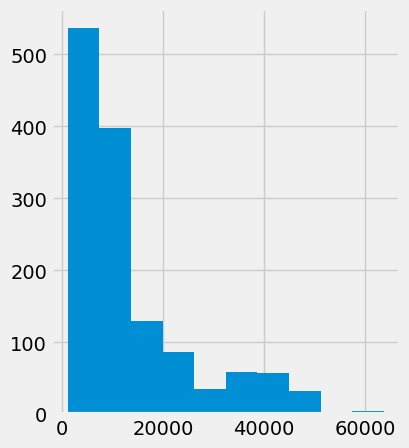

In [8]:
df.charges.hist()

The distribution of charges (medical expenses) follows a classic power-law distribution. As indicated in the summary statistics above, the mean is notably higher than the median, suggesting that the average is significantly skewed by a small number of high-cost outliers. Most individuals paid less than 10,000, and 50% of the data falls below 9,382.03.

In cases like this, where the distribution is heavily skewed, linear regression models tend to perform poorly on lower values. To mitigate this, a common approach is to apply a logarithmic transformation to normalize the distribution.

Accordingly, we will apply the np.log1p() function to the charges variable in the modeling phase, aiming to improve performance by approximating a normal distribution.

---

charges（医療費）の分布を確認すると、典型的な冪乗則（パワーロー分布）に従っていることが分かります。上部の統計情報からも分かるように、平均値は中央値より右側（より大きい値）に位置しており、これは一部の外れ値が平均に大きな影響を与えていることを意味します。多くのサンプルでは10,000未満の費用が支払われており、全体の50%は9,382.03以下となっています。

このような非対称分布では、線形回帰モデルは小さい値の予測精度が低下しやすい傾向があります。そのため、対数変換を行い、分布を正規化してからモデルを学習させる手法が一般的に用いられます。

今後のモデル学習の段階では、charges変数に np.log1p() 関数を適用し、正規分布に近づけた状態で回帰モデルの学習を行う予定です。

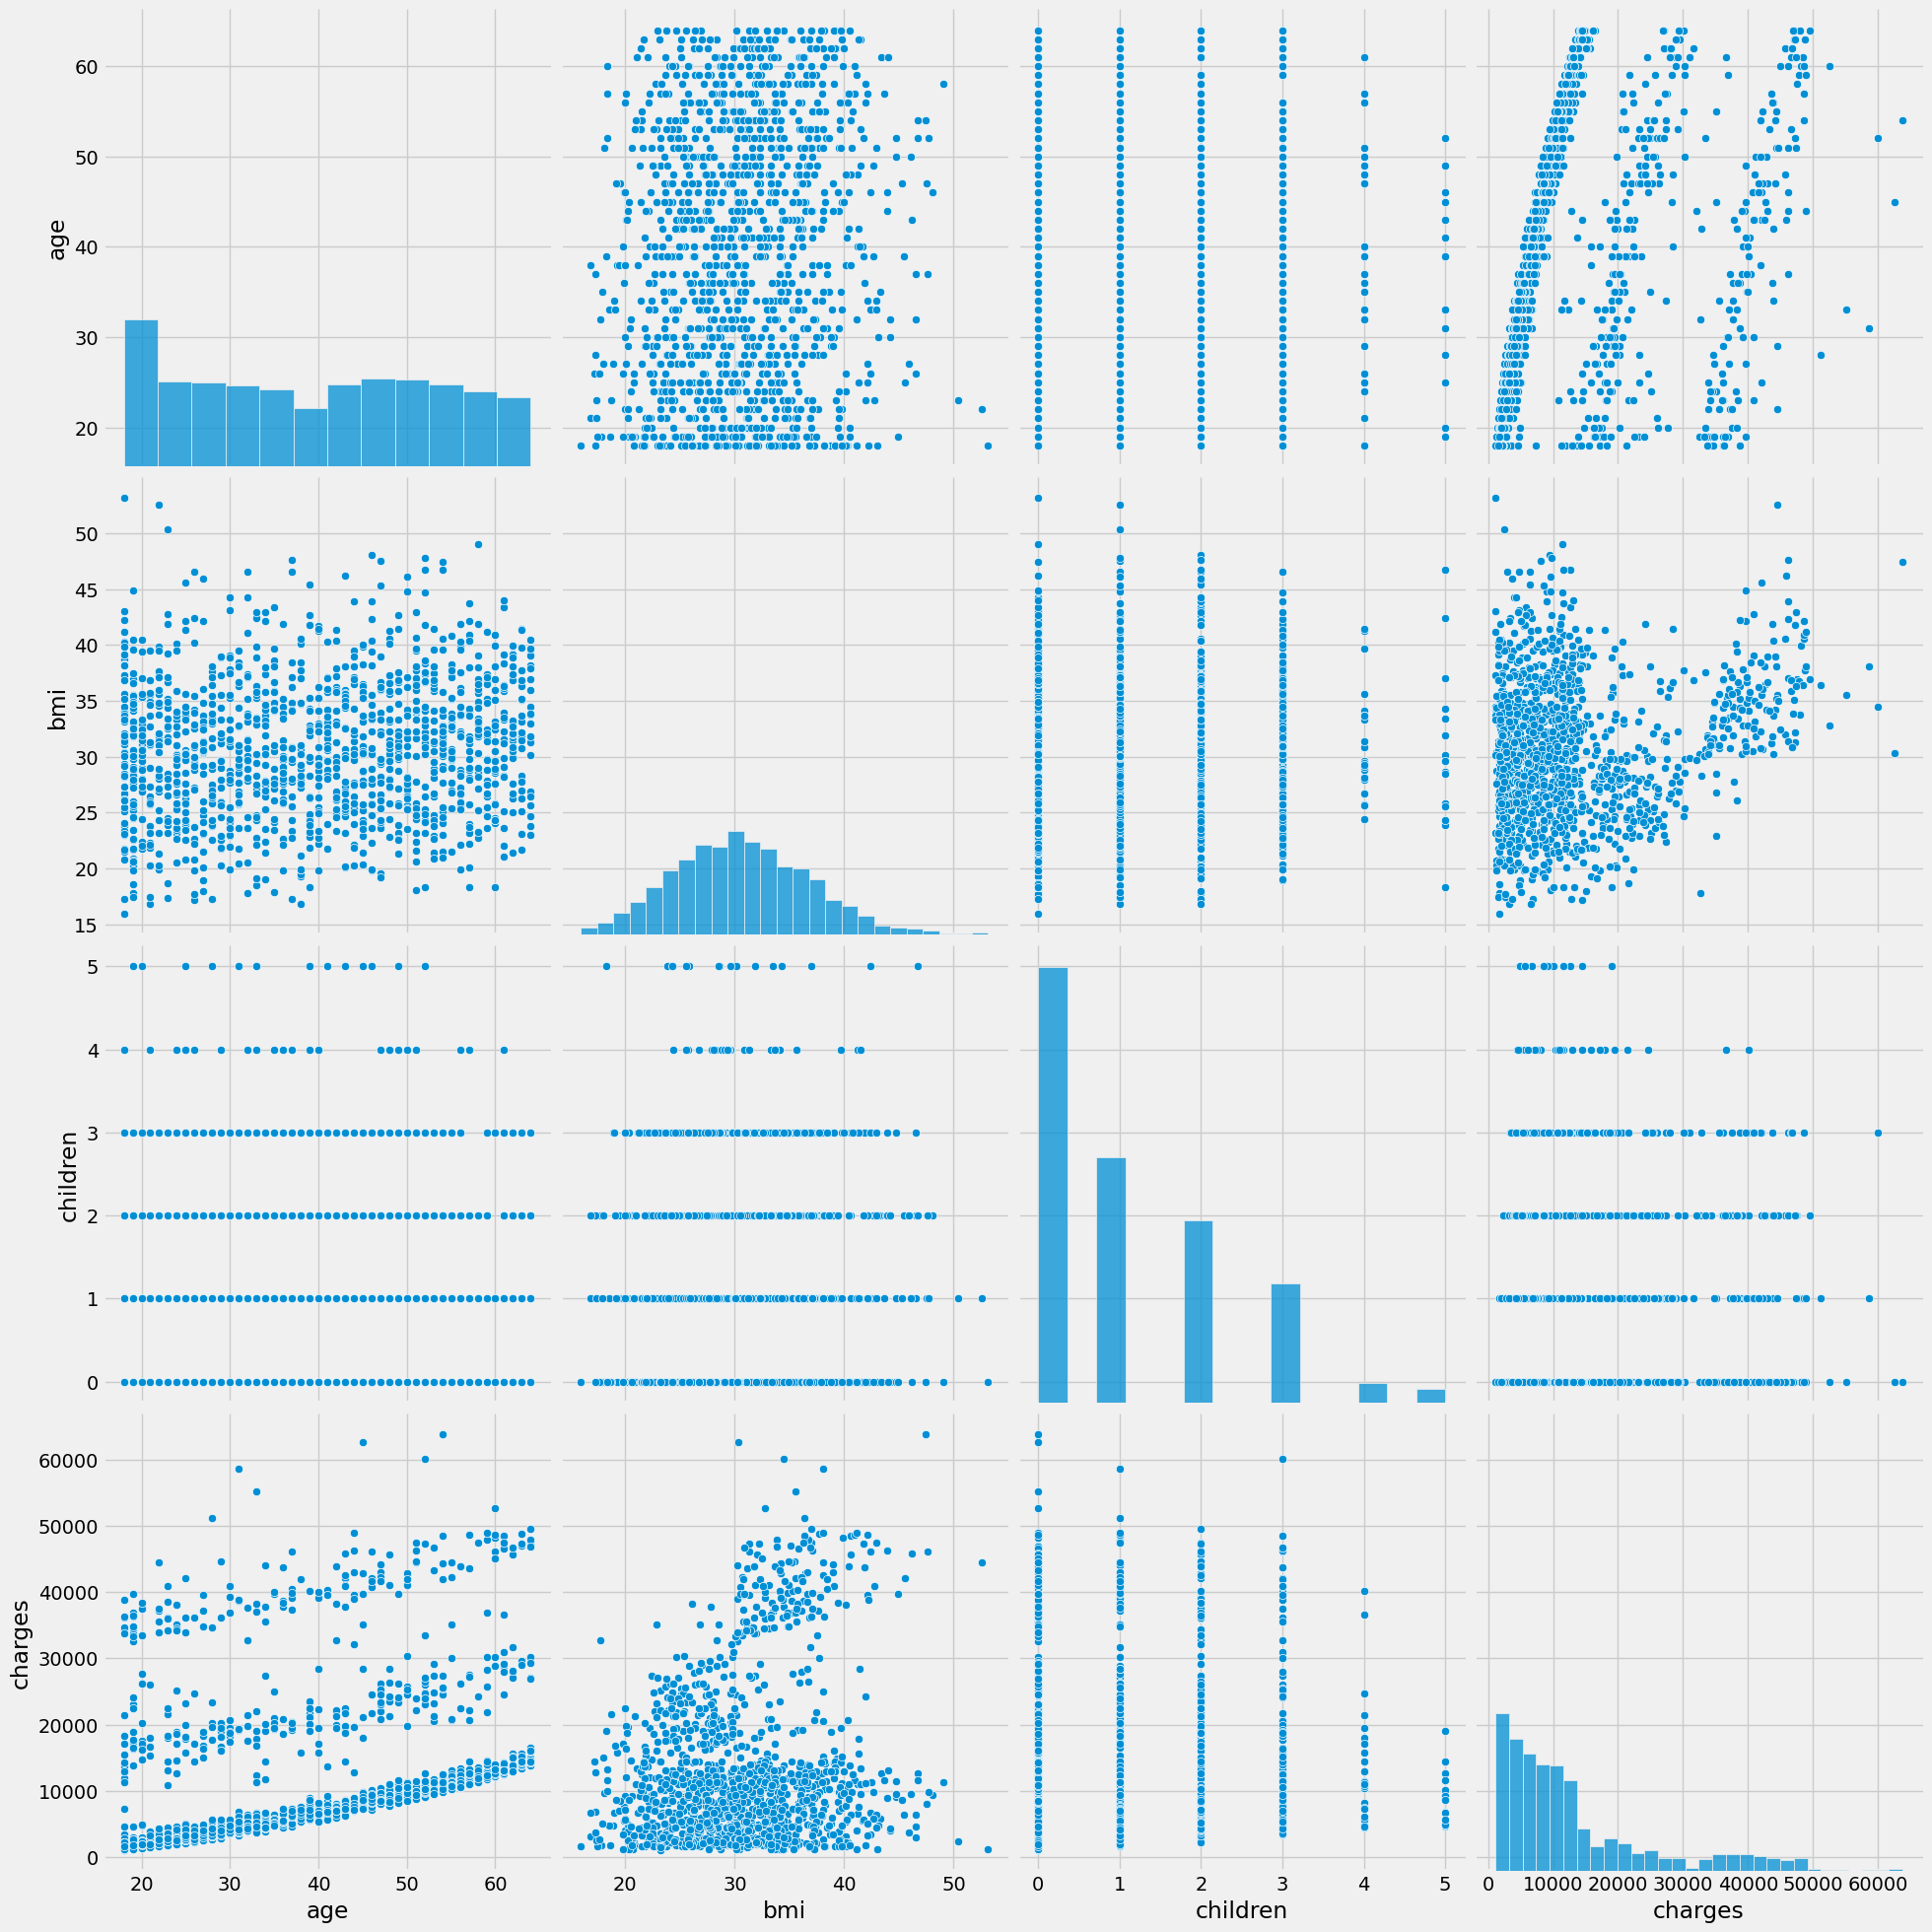

In [9]:
sns.pairplot(data= df, size = 5)

Analyzing the distributions of the numerical variables, we observe that BMI follows a roughly normal distribution, while both children and charges exhibit characteristics of a power-law distribution.

There is a clear positive linear relationship between age and charges. Interestingly, the data appears to cluster into three distinct upward-sloping lines, suggesting the existence of subgroups based on cost brackets.

Examining the relationship between BMI and charges, we find that most high-cost individuals have a BMI above 30, indicating a potential link between obesity and medical expenses.

For the children variable, it appears that individuals with four or more children tend to incur lower medical costs on average.

Based on these initial observations, we will now perform a more detailed correlation analysis among the variables.

---

数値型変数の分布を確認したところ、BMI は比較的正規分布に近い形を示しました。一方、children と charges は 冪乗則（パワーロー分布）の傾向を持っていることが分かります。

age と charges には明確な正の線形関係が見られ、さらに興味深いことに、データは3つの異なる直線的なグループに分かれているように見えます。これは費用帯によって患者群が分かれている可能性を示唆します。

BMI と charges の関係を見ると、高額な医療費を支払っている個人の多くがBMI30以上であることが分かり、肥満と医療費との関連性を示唆しています。

children に関しては、4人以上の子供を持つサンプルでは、平均的に医療費が低い傾向が見られます。

これらの初期観察を踏まえ、変数間の相関関係をさらに詳しく分析していきます。

In [10]:
num_cols = df.select_dtypes(include=np.number)
num_cols.corr().style.background_gradient()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In this section, we will analyze both the distribution of categorical variables and their relationship with charges (medical expenses). By visualizing the characteristics of each category and comparing group-level differences, we aim to explore the impact of categorical features on the target variable.

---

ここでは、カテゴリ変数が charges（医療費）に与える影響の関係性を分析します。各カテゴリの特徴とグループ間の費用差を視覚化することで、カテゴリ変数とターゲット変数との関連性を探っていきます。

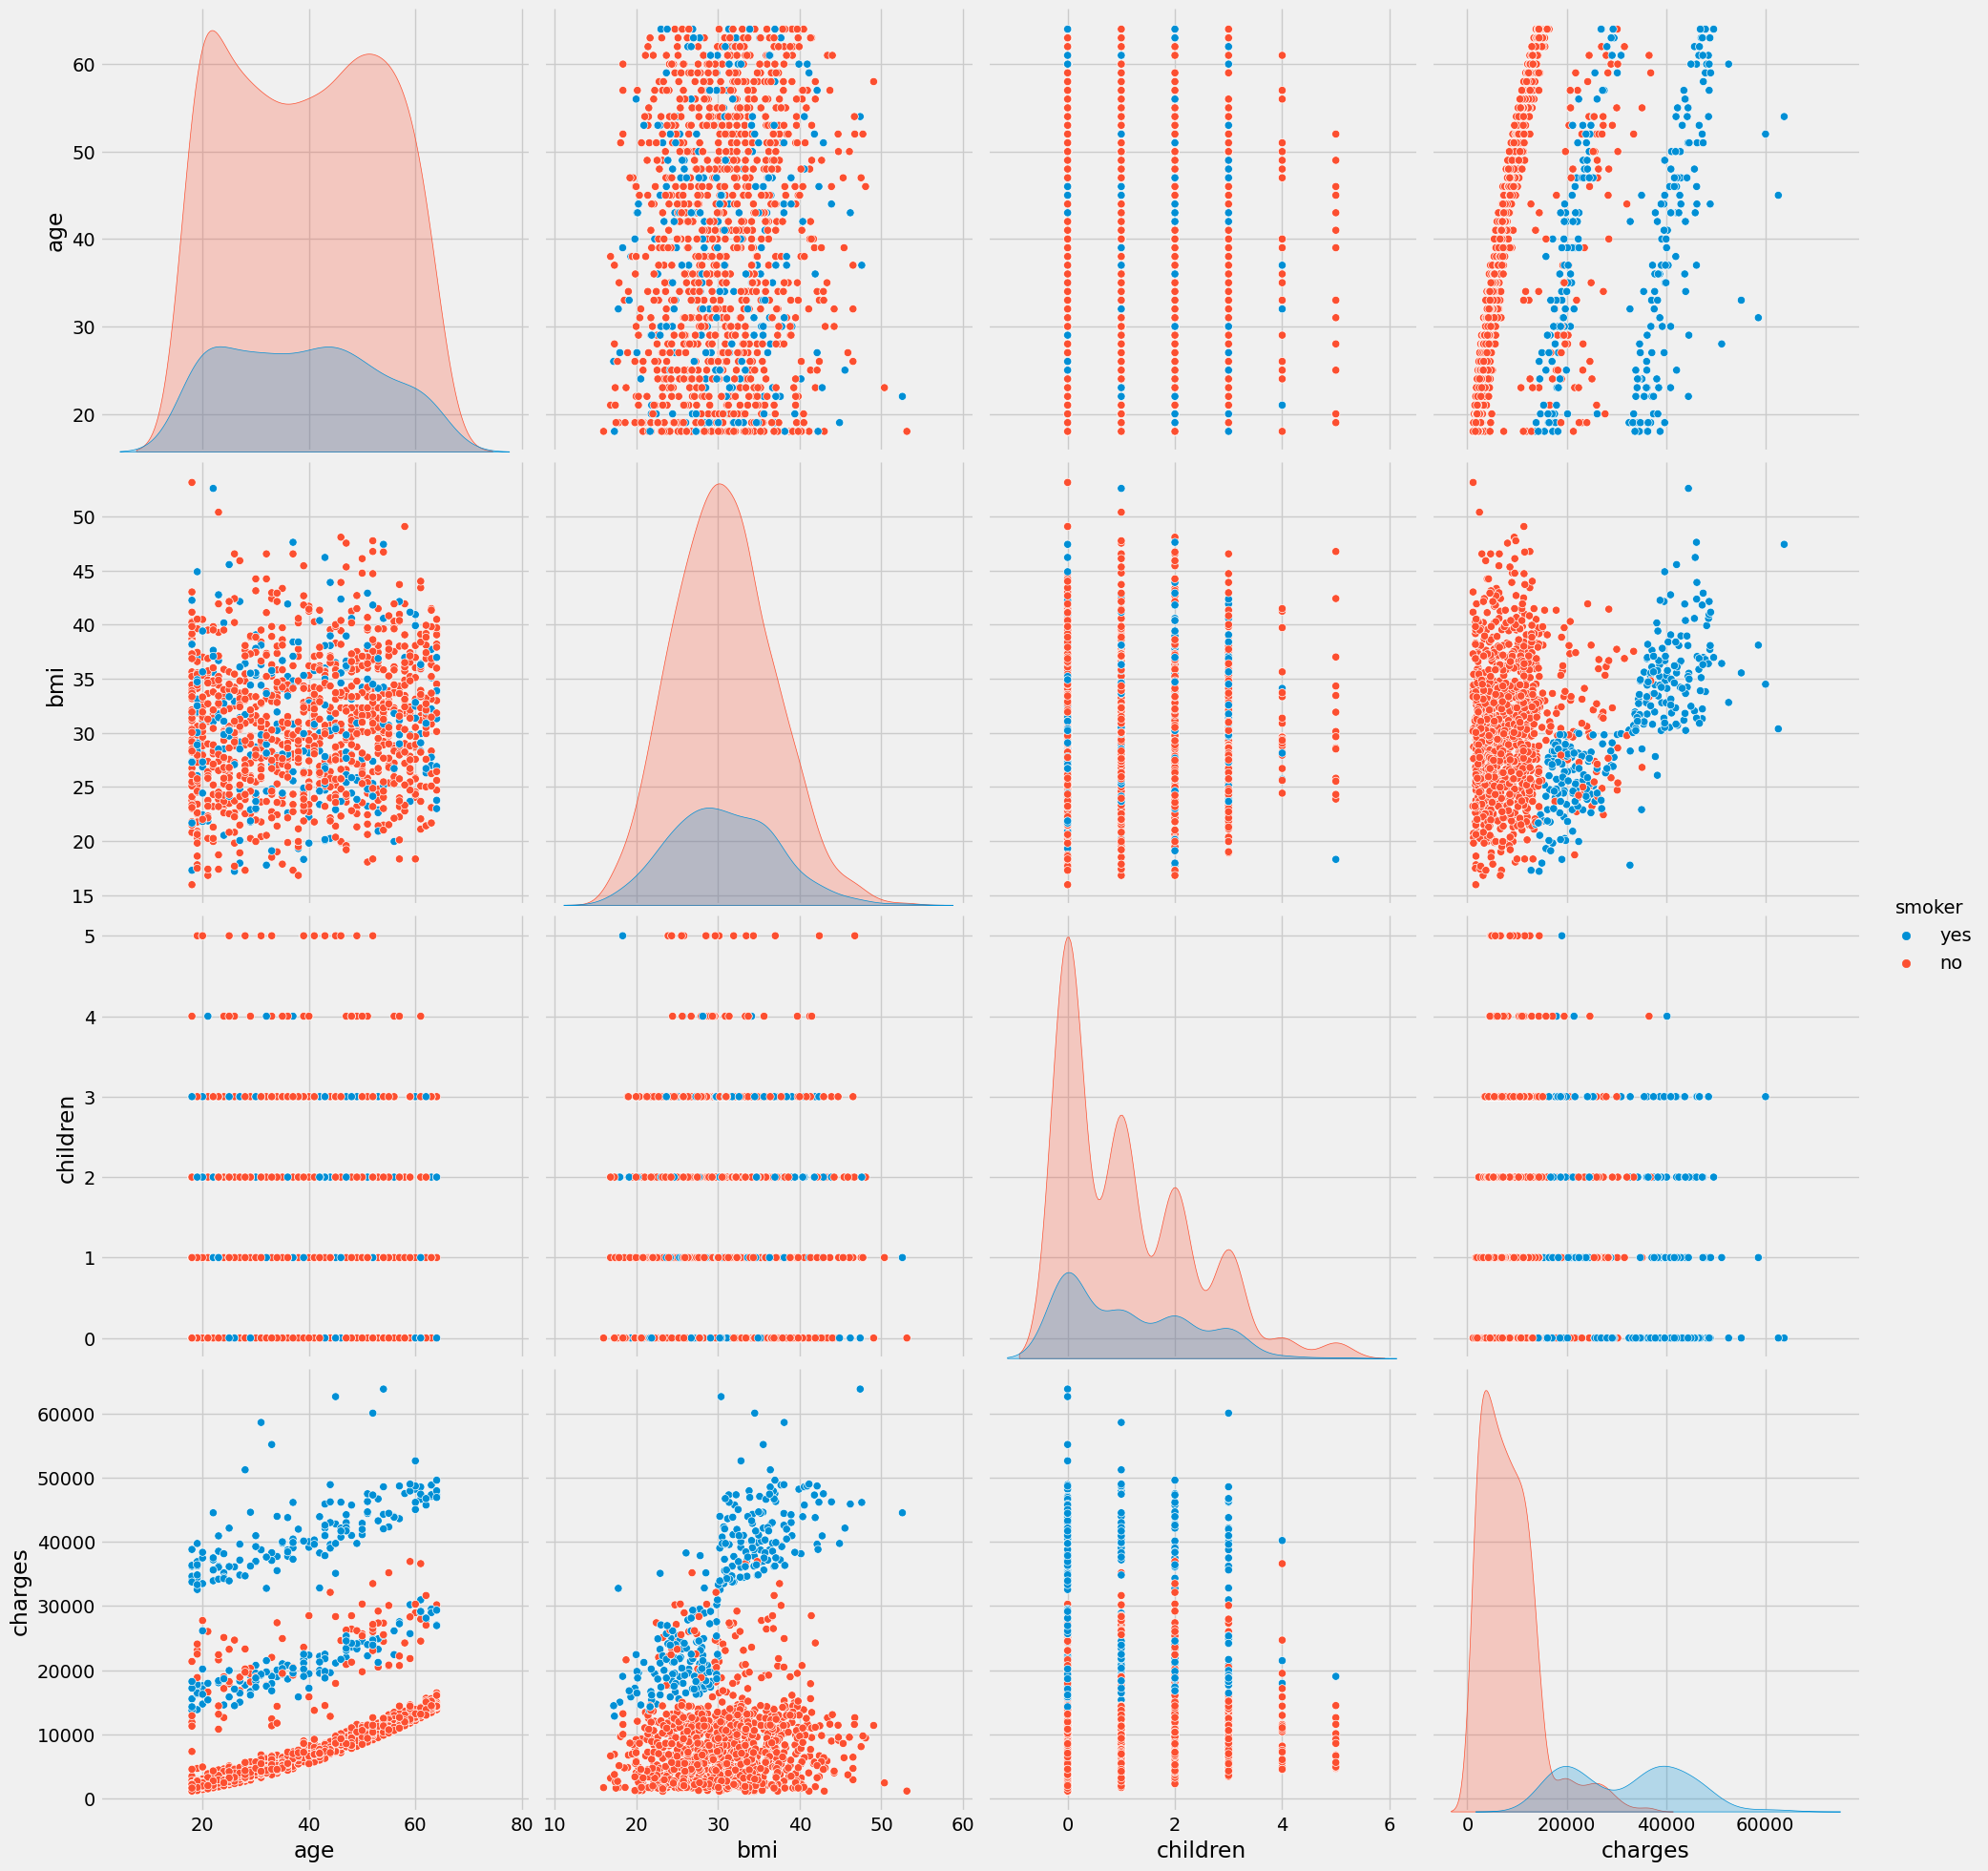

In [11]:
sns.pairplot(data= df, size = 5, hue = 'smoker')

In the visualization, blue represents smokers, while orange represents non-smokers. The distributions of medical charges differ significantly between the two groups, with smokers generally incurring higher and more variable costs.

This suggests that smoking status has a substantial impact on medical expenses, and the smoker variable is likely to be a strong predictor in the modeling phase.

---

可視化された分布において、青色は喫煙者、オレンジ色は非喫煙者を示しています。両グループの費用分布には明確な違いが見られ、特に喫煙者は全体的に費用が高く、分散も大きい傾向があります。

この結果から、喫煙の有無が医療費に大きな影響を与えていることが分かり、smoker 変数は予測モデルにおいて重要な説明変数となる可能性が高いと考えられます。

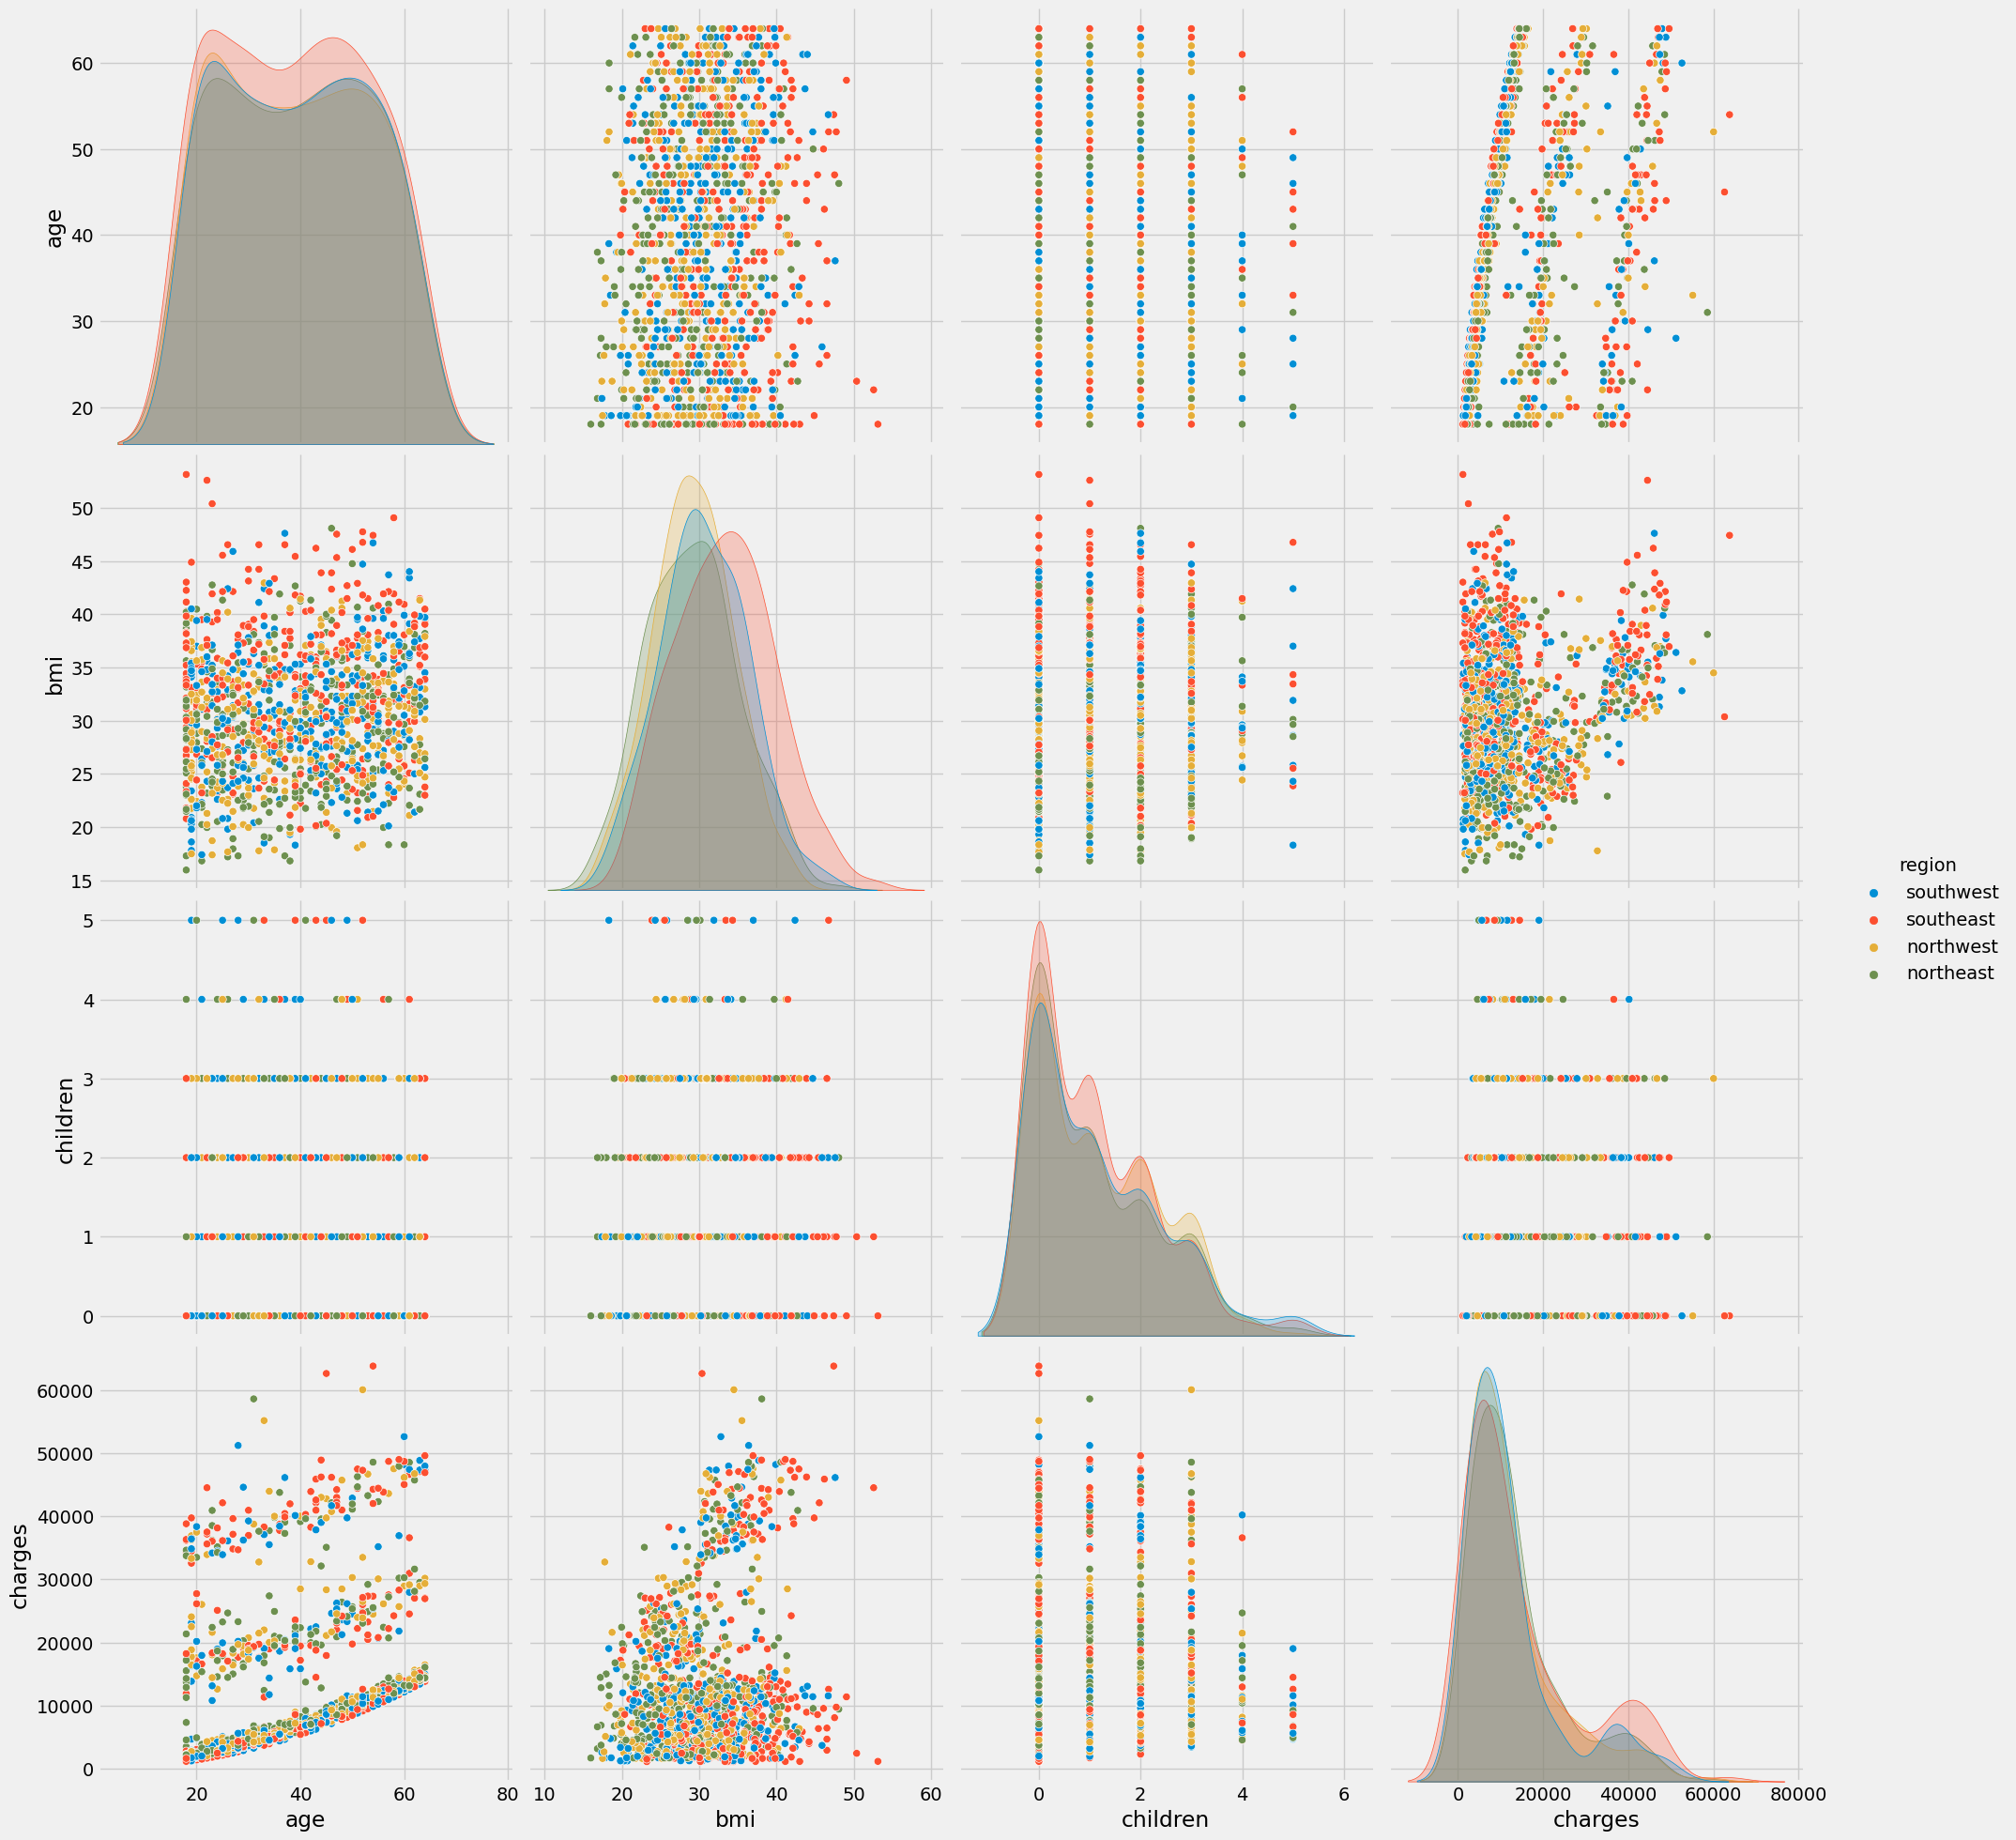

In [12]:
sns.pairplot(data= df, size = 5, hue = 'region')

Overall, it looks similar, but in a perspective of BMI, it seems like they have different BMI distribution depending on the regions. 

---

全体的には、あまり変わらないですが、地域によって、BMIの分布には微差があるように見えます。

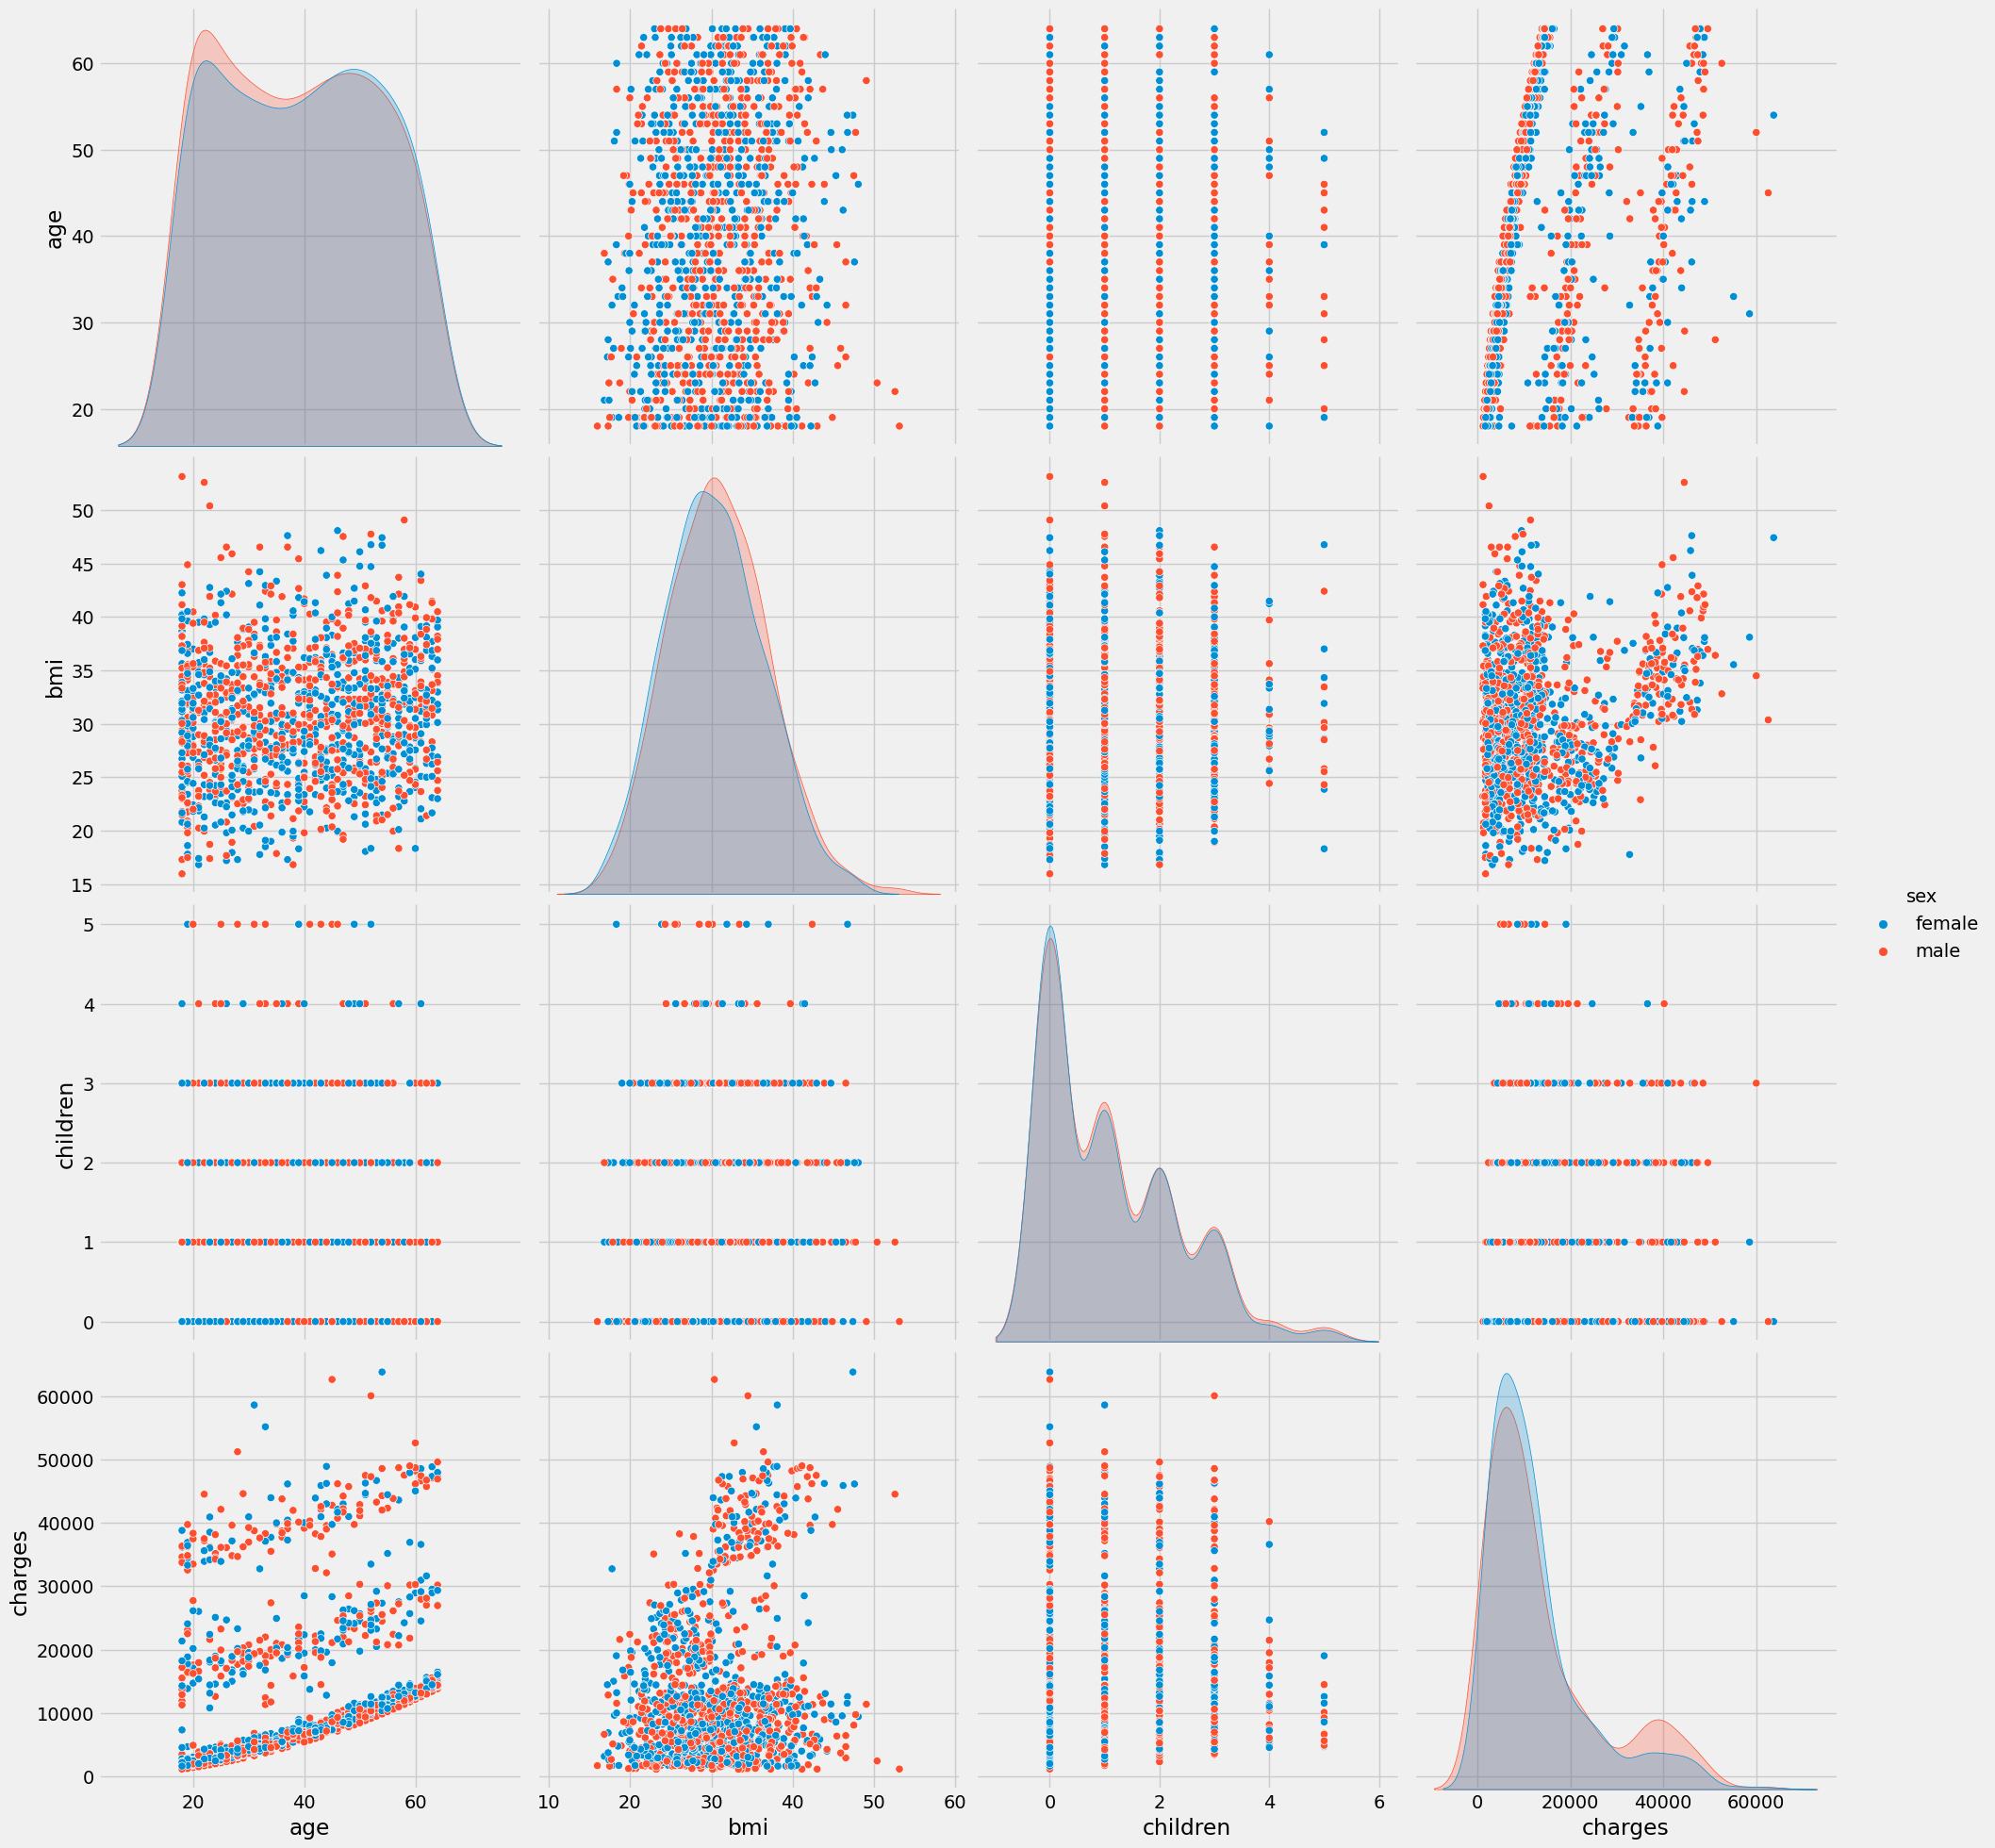

In [13]:
sns.pairplot(data= df, size = 5, hue = 'sex')

For the region and sex variables, the distribution of charges across different groups does not show any significant visual differences. We will now proceed with a more detailed numerical analysis to examine potential differences based on statistical metrics.

---

region（地域）や sex（性別）の各グループにおいては、顕著な分布の違いは確認されませんでした。そこで次に、数値的な指標を用いてグループ間の費用差をより詳細に分析していきます。

In [14]:
# Group by 'smoker' column and calculate the average 'charges' for each group
smoker_charges = df.groupby('smoker')['charges'].mean().sort_values(ascending=False)
print("--- Average Medical Expenses by Smoking Status ---")
print(smoker_charges)

print("\n" + "="*30 + "\n")

# Average medical expenses by gender  
sex_charges = df.groupby('sex')['charges'].mean().sort_values(ascending=False)
print("--- Average Medical Expenses by Gender ---")
print(sex_charges)

print("\n" + "="*30 + "\n")


# Average medical expenses by region  
region_charges = df.groupby('region')['charges'].mean().sort_values(ascending=False)
print("--- Average Medical Expenses by Region ---")
print(region_charges)


--- Average Medical Expenses by Smoking Status ---
smoker
yes    32050.231832
no      8434.268298
Name: charges, dtype: float64


--- Average Medical Expenses by Gender ---
sex
male      13956.751178
female    12569.578844
Name: charges, dtype: float64


--- Average Medical Expenses by Region ---
region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges, dtype: float64


First, we observe that the average medical cost for smokers is nearly four times higher than that of non-smokers, indicating that smoking status is a highly influential factor in determining medical expenses.

In contrast, the average difference in charges by gender is approximately 1,400, and the difference among regions is also around 1,400. This suggests that gender and region may have relatively limited influence on medical charges.

Next, we will numerically assess the correlations between categorical variables and charges. Due to recent updates in the pandas library, categorical variables must be explicitly converted into numerical values to compute correlation coefficients. Therefore, we will manually encode the categorical features before proceeding with the correlation analysis.

---

まず、喫煙者と非喫煙者の平均医療費には約4倍もの差があることが確認できます。これは、喫煙の有無が charges（医療費）に対して非常に強い影響を持つ要因であることを示唆しています。

一方で、性別による平均費用の差は約1,400であり、地域ごとの違いも同様に約1,400の範囲内に収まっています。これは、性別や地域が医療費に与える影響は比較的小さい可能性があることを意味します。

続いて、カテゴリ変数と charges との数値的な相関関係を調べます。

In [15]:
# Convert categorical variables to one-hot encoded format  
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
# 더미 변수, 상관계수는, 흡연 유무의 평균에 따른 상관관계값으로 나타남.

# Compute the correlation matrix
correlation_matrix = df_encoded.corr()

# Extract and sort the correlation between 'charges' and other variables in descending order  
charges_correlation = correlation_matrix['charges'].sort_values(ascending=False)

print("--- coefficient with Charges ---")
print(charges_correlation)

--- coefficient with Charges ---
charges             1.000000
smoker_yes          0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex_male            0.057292
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64


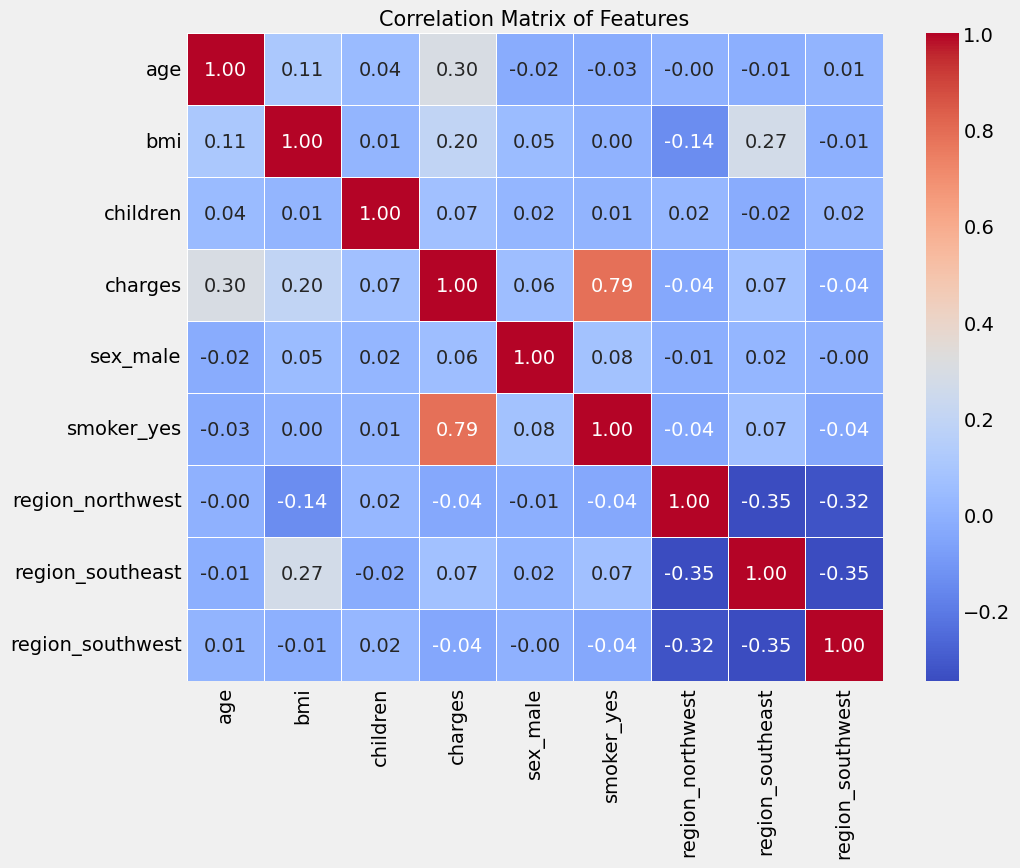

In [16]:
# --- Heatmap Visualization ---  
plt.figure(figsize=(10, 8)) 

# Use sns.heatmap() to generate the heatmap  
# annot=True : display numerical values in each cell  
# cmap='coolwarm' : specify the colormap (red for positive, blue for negative correlations)  
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)

plt.title('Correlation Matrix of Features', fontsize=15)
plt.show()

In [17]:
styled_correlation = charges_correlation.to_frame().style.background_gradient(cmap='coolwarm')
styled_correlation

,charges
charges,1.000000
smoker_yes,0.787251
age,0.299008
bmi,0.198341
region_southeast,0.073982
children,0.067998
sex_male,0.057292
region_northwest,-0.039905
region_southwest,-0.043210


Notably, smoking status shows a strong positive correlation with medical expenses (charges).

The computed correlation coefficient is 0.7872, indicating that smokers tend to incur significantly higher medical costs. This result suggests that the smoker variable may serve as a highly influential predictor in modeling.

---

顕著なのは、喫煙の有無が医療費（charges）と強い正の相関関係を示している点です。

計算された相関係数は0.7872であり、このことから喫煙者は高い医療費を支払う傾向があることがわかります。そして、この結果は、smoker 変数が予測モデルにおいて非常に強力な説明変数となる可能性が高いことを示唆しています。

# 2. Model Training and Evaluation

## Concept
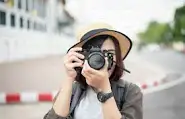
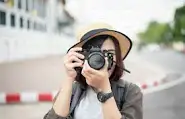

## 2-1. Import Libraries

In [18]:
# 0. Import necessary libraries  
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from xgboost import XGBRegressor
import optuna

# Suppress warnings and logging output  
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.CRITICAL)

print("=" * 80)
print("COMPREHENSIVE ML PIPELINE: Base → Optimized → Ensemble")
print("4 Algorithms × 2 Feature Sets × 2 Target Types × 3 Stages")
print("=" * 80)

COMPREHENSIVE ML PIPELINE: Base → Optimized → Ensemble
4 Algorithms × 2 Feature Sets × 2 Target Types × 3 Stages


## 2-2. Load data and split into Train/Test Set

#### Normalization of the Target Variable
Exploratory Data Analysis (EDA) revealed that the target variable, charges, does not follow a normal distribution, but instead resembles a power-law distribution.
In general, power-law distributions make it difficult for models to accurately predict small values, which can lead to biased or unstable model performance.

To address this, we compare two versions of the target variable: one using the original scale and the other transformed using a logarithmic transformation. This allows us to assess how normalization of the target variable affects model performance.
For models trained on the log-transformed target variable, the predicted outputs must be inverse-transformed to return them to the original scale. We achieve this using np.expm1.

##### Distribution of the Target Variable by Dataset
We split the data into training (80%) and test (20%) sets.
To ensure that the distribution of the target variable is preserved across both sets, we use the stratify parameter during the split.
Since the target variable is continuous, stratified splitting is not directly applicable. To overcome this, we divide the target variable into deciles (10 quantile bins) and treat it as a categorical variable solely for the purpose of stratification.
This approach ensures that the distribution of the target variable remains consistent across the training and test sets.

---

#### 目的変数の正規化
探索的データ分析（EDA）の結果、予測対象である charges（医療費） は正規分布ではなく、ベキ乗分布（power-law distribution） に近い形状を示していることが確認されました。
ベキ乗分布は小さい値に対する予測精度が低くなる傾向があり、モデルの性能に偏りが生じる可能性があります。

この問題に対処するため、目的変数に対して

- 元のスケール（非変換）

- 対数変換（log transformation）

の二つのバージョンを使って、モデルの性能を比較します。これにより、目的変数の正規化がモデルの予測精度に与える影響を検証することができます。
なお、対数変換後のデータで学習したモデルの予測値は、最終的に 元のスケールへ逆変換する必要があります。その際には、np.expm1 を使用します。

#### データセット別における目的変数の分布
データは、80%をトレーニングセット、20%をテストセットとして分割します。
この際、トレーニングセットとテストセット間で目的変数の分布が可能な限り一致するようにするため、stratify を行います。

しかし、目的変数が連続値であるため、そのままでは層化ができません。そこで、目的変数を 10分位（decile） に分割し、カテゴリ変数として扱うことで層化の条件を満たすように工夫しました。
この方法により、トレーニングセットとテストセットの目的変数分布を均等に保つことが可能になります。

In [19]:
# 1. Load the dataset and perform initial train-test split  
df = pd.read_csv('/kaggle/input/insurance/insurance.csv')
seed = 42
target_col = 'charges'

# Apply log transformation and stratified binning for the target variable  
df['charges_log'] = np.log1p(df[target_col])
df['charges_bin'], bins = pd.qcut(df['charges_log'], q=10, labels=False, retbins=True, duplicates='drop')
# charges_log한 값을 bin으로 묶은 다음에 각 샘플이 bin number를 갖고 있고, 그 bin number에 대한 분포를 알 수가 있음.

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['charges_bin'], random_state=seed)
train_df = train_df.drop(columns=['charges_log', 'charges_bin'])
test_df = test_df.drop(columns=['charges_log', 'charges_bin'])

print(f"📊 Dataset: {len(train_df)} train, {len(test_df)} test samples")

📊 Dataset: 1070 train, 268 test samples


## 2-3. Data Engineering

Before training the model, we first preprocess the categorical variables.
There are two major approaches for handling categorical variables: One-Hot Encoding and Label Encoding, each with different characteristics.

- One-Hot Encoding: Creates new binary columns for each category, assigning 1 if a row belongs to that category and 0 otherwise.

- Label Encoding: Assigns a unique integer to each category. For example, in the region column, categories might be mapped as: Southeast → 1, Southwest → 2, Northeast → 3, Northwest → 4.

While Label Encoding is straightforward, it can introduce unintended ordinal relationships between categories. For instance, even if there is no inherent order among regions, linear models like Linear Regression may mistakenly interpret the encoded values as having linear relationships. Therefore, caution is required when using this method.

In this project, all categorical features—sex, smoker, and region—will be encoded using One-Hot Encoding to avoid such issues.

After completing preprocessing of the categorical variables, we will proceed to train models using two types of datasets:

1. one with second-order polynomial features applied, and

2. one without polynomial transformation.

This comparison will allow us to assess how much the introduction of second-order polynomial features contributes to improving model performance.

As a result, we will have a total of four datasets for modeling:

1. processed_original: original target variable, no polynomial features

2. processed_log: log-transformed target variable, no polynomial features

3. poly_original: original target variable with second-order polynomial features

4. poly_log: log-transformed target variable with second-order polynomial features

---

モデルの学習に先立ち、まず**カテゴリ変数**の前処理を行います。
カテゴリ変数の処理方法には主に2つのアプローチが存在します：One-Hot Encoding（ワンホットエンコーディング）とLabel Encoding（ラベルエンコーディング）です。

- One-Hot Encoding：各カテゴリごとに新たな列を作成し、該当する行には1、それ以外には0を割り当てる手法です。

- Label Encoding：各カテゴリに一意の整数ラベルを割り当てる方法です。例えば、region列に対して、Southeast → 1、Southwest → 2、Northeast → 3、Northwest → 4 などとエンコードします。

Label Encodingは実装が簡単な一方で、カテゴリ間に順位関係が存在しないにもかかわらず、線形回帰モデルなどがその数値を順序的な関係として誤認するリスクがあります。したがって、線形モデルを用いる場合、カテゴリ変数のエンコーディングには注意が必要です。

本プロジェクトでは、カテゴリ変数である sex（性別）、smoker（喫煙者かどうか）、region（地域） の全てに対して、One-Hot Encodingを用いて前処理を行います。

カテゴリ変数の前処理が完了した後は、

1. 2次の多項式特徴量（Polynomial Features） を適用したデータセットと、

2. 適用しないデータセット

の2種類を用いてモデルを学習させます。

この比較を通じて、2次多項式特徴量の導入がモデルの性能向上にどの程度貢献するかを確認します。

最終的に使用するデータセットは、以下の4種類になります：

1. processed_original：目的変数は元のスケール、多項式特徴量なし

2. processed_log：目的変数は対数変換済み、多項式特徴量なし

3. poly_original：目的変数は元のスケール、2次多項式特徴量あり

4. poly_log：目的変数は対数変換済み、2次多項式特徴量あり

In [20]:
# 2. Preprocessing: Binary Label Encoding  
def label_encode(df):
    df = df.copy()
    df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
    df['sex'] = df['sex'].map({'male': 1, 'female': 0})
    return df

train_df = label_encode(train_df)
test_df = label_encode(test_df)
# train, test셋의, 흡연, 성별 여부를 0,1로 치환
# 이진 범주형을, onehotencoding 하는 것은 의미 없음.

# 수치형, 범주형 나누기. 
cat_cols = ['region']
num_cols = train_df.select_dtypes(exclude='object').drop(columns=[target_col]).columns

# Initialize preprocessing components  
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train_df[cat_cols]) # 학습

poly = PolynomialFeatures(degree=2, include_bias=False)

# Define feature engineering functions  
def make_features(df_base, fit_poly=False):
    encoded = encoder.transform(df_base[cat_cols])
    encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols), index=df_base.index)
    full_features = pd.concat([df_base[num_cols], encoded_df], axis=1)
    
    if fit_poly:
        poly_features = poly.fit_transform(full_features)
    else:
        poly_features = poly.transform(full_features)
    
    poly_df = pd.DataFrame(poly_features, columns=poly.get_feature_names_out(full_features.columns), index=df_base.index)
    return full_features, poly_df

# Generate features  
X_train_proc, X_train_poly = make_features(train_df, fit_poly=True)
X_test_proc, X_test_poly = make_features(test_df, fit_poly=False)

# Prepare the target variable  
y_train_original = train_df[target_col].values
y_test_original = test_df[target_col].values
y_train_log = np.log1p(y_train_original)
y_test_log = np.log1p(y_test_original)

# 3. Configuration  
features = {
    'processed': (X_train_proc, X_test_proc),
    'poly2': (X_train_poly, X_test_poly)
}

targets = {
    'original': (y_train_original, y_test_original, False),
    'log': (y_train_log, y_test_log, True)
}

models_config = {
    'linear': LinearRegression(),
    'lightgbm': LGBMRegressor(
        learning_rate=0.05, n_estimators=200, num_leaves=31, max_depth=7,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=0.1, random_state=seed, verbosity=-1
    ),
    'xgboost': XGBRegressor(
        learning_rate=0.05, n_estimators=200, max_depth=7, min_child_weight=20,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
        random_state=seed, verbosity=0
    ),
    'randomforest': RandomForestRegressor(
        n_estimators=200, max_depth=10, min_samples_split=20, min_samples_leaf=10,
        max_features=0.8, random_state=seed, n_jobs=-1
    )
}


In [21]:
X_train_proc.head()


,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
806,40,0,41.420,1,0,0.0,1.0,0.0,0.0
346,33,1,35.750,2,0,0.0,0.0,1.0,0.0
453,20,1,29.735,0,0,0.0,1.0,0.0,0.0
1134,28,1,33.820,0,0,0.0,1.0,0.0,0.0
220,34,0,33.700,1,0,0.0,0.0,0.0,1.0


In [22]:
X_train_poly.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest,age^2,...,region_northeast^2,region_northeast region_northwest,region_northeast region_southeast,region_northeast region_southwest,region_northwest^2,region_northwest region_southeast,region_northwest region_southwest,region_southeast^2,region_southeast region_southwest,region_southwest^2
806,40.0,0.0,41.420,1.0,0.0,0.0,1.0,0.0,0.0,1600.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
346,33.0,1.0,35.750,2.0,0.0,0.0,0.0,1.0,0.0,1089.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
453,20.0,1.0,29.735,0.0,0.0,0.0,1.0,0.0,0.0,400.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1134,28.0,1.0,33.820,0.0,0.0,0.0,1.0,0.0,0.0,784.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
220,34.0,0.0,33.700,1.0,0.0,0.0,0.0,0.0,1.0,1156.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [23]:
X_train_poly.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region_northeast',
       'region_northwest', 'region_southeast', 'region_southwest', 'age^2',
       'age sex', 'age bmi', 'age children', 'age smoker',
       'age region_northeast', 'age region_northwest', 'age region_southeast',
       'age region_southwest', 'sex^2', 'sex bmi', 'sex children',
       'sex smoker', 'sex region_northeast', 'sex region_northwest',
       'sex region_southeast', 'sex region_southwest', 'bmi^2', 'bmi children',
       'bmi smoker', 'bmi region_northeast', 'bmi region_northwest',
       'bmi region_southeast', 'bmi region_southwest', 'children^2',
       'children smoker', 'children region_northeast',
       'children region_northwest', 'children region_southeast',
       'children region_southwest', 'smoker^2', 'smoker region_northeast',
       'smoker region_northwest', 'smoker region_southeast',
       'smoker region_southwest', 'region_northeast^2',
       'region_northeast region_northwest',
      

## 2.4 Model Training and Evaluation

For this project, we selected four algorithms: LinearRegression, RandomForest, XGBoost, and LightGBM. Below is a brief explanation of each model along with the rationale behind their selection.

1. LinearRegression
    - Linear regression is one of the most fundamental regression algorithms, assuming a linear relationship between the target and the independent variables. It is highly interpretable and suitable for understanding the influence of each feature. If the data does not exhibit multicollinearity or significant non-linearity, it can serve as a simple yet effective baseline model.

2. RandomForest
    - Random Forest is an ensemble learning method that combines multiple decision trees to improve predictive performance. It is robust against overfitting and capable of capturing complex non-linear relationships and feature interactions, making it suitable for predicting continuous variables like medical costs, which are influenced by diverse factors.

3. XGBoost
    - XGBoost is a powerful gradient boosting-based ensemble model. It offers fast training and includes built-in regularization to prevent overfitting. It performs well even with noisy or complex datasets and is widely known for achieving top performance in Kaggle competitions.

4. LightGBM
    - LightGBM is similar to XGBoost but optimized for higher speed and lower memory usage. It is especially effective for large datasets or those with numerous categorical features. LightGBM is also known for delivering strong performance in regression tasks such as medical cost prediction.

These models represent a diverse set of approaches to regression problems. Gradient boosting models like XGBoost and LightGBM, in particular, are frequently used in top solutions for competitions such as Kaggle, which is why they were chosen for this project.

--- 

本プロジェクトでは、以下の4つのアルゴリズムを選択しました：LinearRegression、RandomForest、XGBoost、LightGBM。それぞれのモデルの概要と選定理由について簡潔に説明します。

1. LinearRegression（線形回帰）
    - 線形回帰は最も基本的な回帰アルゴリズムの一つで、目的変数と説明変数の間に線形関係があると仮定します。モデルの解釈が直感的で、各変数の影響力を理解するのに適しています。データに多重共線性や非線形性が大きくない場合、シンプルながら有効なベースラインモデルとして活用できます。

2. RandomForest（ランダムフォレスト）
    - ランダムフォレストは複数の決定木（Decision Tree）をアンサンブルすることで予測性能を向上させるモデルです。過学習に強く、非線形な関係や変数間の相互作用も捉えることができるため、さまざまな要因に影響される医療費のような連続値データの予測に適しています。
    - Key Parameters : min_leaf_sample, depth

3. XGBoost
    - XGBoostは勾配ブースティングに基づく高性能なアンサンブルモデルであり、高速な学習と組み込みの正則化機能により過学習を防ぎます。複雑でノイズの多いデータに対しても高い予測精度を誇り、Kaggleなどの競技会でも高評価を得ているモデルです。
    - depth, n_estimators

4. LightGBM
    - LightGBMはXGBoostに類似したブースティングモデルですが、より高速でメモリ効率に優れるように設計されています。特に大規模データやカテゴリ変数が多いデータに対して効果的であり、医療費予測のような回帰問題でも高いパフォーマンスを発揮します。

上記のアルゴリズムは、回帰問題における代表的な手法です。特に、XGBoostやLightGBMといった勾配ブースティング系のアルゴリズムは、Kaggleなどのコンペティションにおける上位ソリューションで頻繁に使用されているため、本プロジェクトでも採用しました。

In [24]:
# =====================================================================
# STAGE 1: Baseline model performance comparison  
# =====================================================================
print("\n🔄 STAGE 1: Training base models...")

def train_and_evaluate_model(model, model_name, X_tr, X_te, y_tr, y_te, is_log_target=False):
    """모델 훈련 및 평가 함수"""
    X_tr_sub, X_cv_sub, y_tr_sub, y_cv_sub = train_test_split(
        X_tr, y_tr, test_size=0.2, random_state=seed
    )
    
    # Model Training
    if model_name == 'lightgbm':
        model.fit(X_tr_sub, y_tr_sub, eval_set=[(X_cv_sub, y_cv_sub)],
                 callbacks=[early_stopping(stopping_rounds=20), log_evaluation(period=0)])
    elif model_name == 'xgboost':
        model.fit(X_tr_sub, y_tr_sub, eval_set=[(X_cv_sub, y_cv_sub)],
                 early_stopping_rounds=20, verbose=False)
    else:
        model.fit(X_tr_sub, y_tr_sub)
    
    # Prediction
    pred_train = model.predict(X_tr_sub)
    pred_cv = model.predict(X_cv_sub)
    pred_test = model.predict(X_te)
    
    # Apply inverse log transformation
    if is_log_target:
        pred_train = np.expm1(pred_train)
        pred_cv = np.expm1(pred_cv)
        pred_test = np.expm1(pred_test)
        y_tr_eval = np.expm1(y_tr_sub)
        y_cv_eval = np.expm1(y_cv_sub)
        y_te_eval = np.expm1(y_te)
    else:
        y_tr_eval = y_tr_sub
        y_cv_eval = y_cv_sub
        y_te_eval = y_te
    
    return {
        'train_rmse': round(mean_squared_error(y_tr_eval, pred_train, squared=False), 4),
        'train_mae': round(mean_absolute_error(y_tr_eval, pred_train), 4),
        'train_r2': round(r2_score(y_tr_eval, pred_train), 4),
        'cv_rmse': round(mean_squared_error(y_cv_eval, pred_cv, squared=False), 4),
        'cv_mae': round(mean_absolute_error(y_cv_eval, pred_cv), 4),
        'cv_r2': round(r2_score(y_cv_eval, pred_cv), 4),
        'test_rmse': round(mean_squared_error(y_te_eval, pred_test, squared=False), 4),
        'test_mae': round(mean_absolute_error(y_te_eval, pred_test), 4),
        'test_r2': round(r2_score(y_te_eval, pred_test), 4)
    }

base_results = []
for model_name, model in models_config.items():
    for feat_name, (X_tr, X_te) in features.items():
        for target_name, (y_tr, y_te, is_log) in targets.items():
            metrics = train_and_evaluate_model(model, model_name, X_tr, X_te, y_tr, y_te, is_log)
            metrics.update({
                'model': f'{model_name}_{feat_name}_{target_name}',
                'algorithm': model_name,
                'features': feat_name,
                'target': target_name,
                'stage': 'base'
            })
            base_results.append(metrics)

base_results_df = pd.DataFrame(base_results)
print("✅ Base models completed!")
print(base_results_df)


🔄 STAGE 1: Training base models...
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[92]	valid_0's l2: 1.62021e+07
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[80]	valid_0's l2: 0.116356
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[72]	valid_0's l2: 1.62885e+07
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[73]	valid_0's l2: 0.121471
✅ Base models completed!
    train_rmse  train_mae  train_r2    cv_rmse     cv_mae   cv_r2  test_rmse  \
0    6131.8541  4313.1442    0.7432  5676.5362  4155.1718  0.7674  6112.5345   
1    8103.4093  4160.2353    0.5516  7553.6085  4013.6860  0.5882  8454.9720   
2    4741.4011  2942.2099    0.8465  4448.4111  2857.3298  0.8572  5086.5816   
3    5064.4890  2656.1577    0.8248  4730.6784  2585.9541  0.8385  5163.2859   
4    3690.5891  2109.1360    0.9070  

For model evaluation, I utilized three commonly used metrics: MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), and R² (Coefficient of Determination). Below is a brief explanation of each metric and the rationale behind their selection.

1. MAE (Mean Absolute Error)
    - MAE represents the average of the absolute differences between the actual and predicted values. Its interpretation is intuitive, making it easy to communicate and understand. One of its main advantages is its robustness to outliers, as it treats all errors equally. MAE gives a clear sense of how far off, on average, the predictions are from the actual values.

2. RMSE (Root Mean Squared Error)
    - RMSE is the square root of the average of squared differences between actual and predicted values. It penalizes larger errors more heavily than MAE, making it sensitive to outliers. This metric is particularly useful when we want to emphasize large prediction errors and evaluate how consistently the model predicts without large deviations.

3. R² (Coefficient of Determination)
    - R² indicates the proportion of variance in the target variable that can be explained by the input features. It ranges from 0 to 1, where values closer to 1 signify better model performance. This metric provides insight into the overall explanatory power of the model.

Using multiple evaluation metrics simultaneously is crucial for a comprehensive assessment. Each metric captures a different aspect of model performance. While MAE offers a view of the average prediction error, RMSE highlights the impact of larger errors. R², on the other hand, measures how well the model captures the underlying patterns in the data. By combining these metrics, we can evaluate not only the model's average prediction accuracy, but also its sensitivity to large deviations and its overall explanatory strength.

---

モデルの評価にあたっては、代表的な3つの指標である MAE（平均絶対誤差）、RMSE（二乗平均平方根誤差）、R²（決定係数） を使用しました。それぞれの評価指標の概要と、選定理由を以下に示します。

1. MAE（Mean Absolute Error：平均絶対誤差）
    - MAEは、実測値と予測値の絶対誤差の平均を示します。解釈が直感的でわかりやすく、すべての誤差を同じ重みで扱うため、外れ値に対して頑健であるという利点があります。予測値が実際の値と平均的にどれだけズレているかを把握するのに適しています。

2. RMSE（Root Mean Squared Error：二乗平均平方根誤差）
    - RMSEは、誤差を二乗して平均を取り、それに平方根を適用したものです。大きな誤差に対してより強くペナルティを与えるため、MAEよりも外れ値に敏感です。大きな誤差の影響を強調してモデルを評価したいときに有効な指標です。

3. R²（決定係数）
    - R²は、入力変数が目的変数をどの程度説明できるかを示す指標で、0から1の範囲の値を取ります。値が1に近いほど、モデルがデータをよく説明していることを意味します。モデルの全体的な説明力を把握する上で効果的です。

モデルの性能を正確に評価するには、複数の評価指標を併用することが重要です。なぜなら、各指標が捉える視点が異なるからです。例えば、MAEは予測誤差の平均的な大きさを示し、RMSEは大きな誤差に敏感に反応します。一方で、R²はモデルの説明力を総合的に評価します。これらの指標を組み合わせることで、単に平均的な精度だけでなく、外れ値への感度やモデルの構造的な適合度まで、多面的な評価が可能となります。

Based on the R² and RMSE evaluation metrics, models trained on the log-transformed datasets consistently demonstrated better performance than those trained on the original scale. Among the algorithms tested, Linear Regression showed the weakest performance, while Random Forest slightly outperformed the others, achieving the best results overall.

In terms of dataset variation, the poly2_log dataset — which combines log-transformation with second-degree polynomial features — led to the greatest improvement in model performance. This suggests that both target variable normalization and feature expansion contribute meaningfully to enhancing prediction accuracy.

---

R²およびRMSEの評価指標をもとに比較した結果、ログ変換を施したデータセットで学習したモデルが一貫してより高い性能を示しました。使用したアルゴリズムの中では、Linear Regressionが最も低い性能を 보였のに対し、Random Forestがわずかに他モデルを上回り、最も良い結果を達成しました。

データの前処理バリエーションにおいては、ログ変換と2次の多項식特徴量を組み合わせた poly2_log データセットが、最もモデル性能を向上させる結果となりました。これは、ターゲット変数の正規화と特徴量の非선형拡張の両方が、予測精度の向上に有効であることを示唆しています。

## 2-5. Hyperparameter Optimization for LightGBM

In the previous models, the hyperparameters for LightGBMRegressor, XGBoost, RandomForest were manually adjusted. In this section, we utilize the Optuna library to automatically optimize the hyperparameters, train the model using the best configuration, and evaluate its predictive performance.

---
前節のモデルでは、LightGBMRegressor, XGBoost, RandomForest のハイパーパラメータを手動で調整しました。本節では、Optuna ライブラリを活用してハイパーパラメータを自動的に最適化し、最適な設定でモデルを学習させた後、その予測性能を評価します。

In [25]:
# =====================================================================
# STAGE 2: Optuna Hyperparameter Optimization  
# =====================================================================
print("\n🔍 STAGE 2: Hyperparameter optimization with Optuna...")

def create_objective(model_name, X_train, y_train, is_log_target=False):
    def objective(trial):
        X_tr_sub, X_val_sub, y_tr_sub, y_val_sub = train_test_split(
            X_train, y_train, test_size=0.2, random_state=seed
        )
        
        if model_name == 'lightgbm':
            params = {
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'n_estimators': 1000,
                'num_leaves': trial.suggest_int('num_leaves', 16, 128),
                'max_depth': trial.suggest_int('max_depth', 3, 12),
                'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
                'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
                'random_state': seed, 'verbosity': -1
            }
            model = LGBMRegressor(**params)
            model.fit(X_tr_sub, y_tr_sub, eval_set=[(X_val_sub, y_val_sub)],
                     callbacks=[early_stopping(15), log_evaluation(period=0)])
                     
        elif model_name == 'xgboost':
            params = {
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'n_estimators': 1000,
                'max_depth': trial.suggest_int('max_depth', 3, 12),
                'min_child_weight': trial.suggest_int('min_child_weight', 5, 50),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
                'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
                'random_state': seed, 'verbosity': 0
            }
            model = XGBRegressor(**params)
            model.fit(X_tr_sub, y_tr_sub, eval_set=[(X_val_sub, y_val_sub)],
                     early_stopping_rounds=15, verbose=False)
                     
        elif model_name == 'randomforest':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 300),
                'max_depth': trial.suggest_int('max_depth', 5, 15),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
                'max_features': trial.suggest_float('max_features', 0.3, 1.0),
                'random_state': seed, 'n_jobs': -1
            }
            model = RandomForestRegressor(**params)
            model.fit(X_tr_sub, y_tr_sub)
        
        preds = model.predict(X_val_sub)
        
        # Evaluate after restoring log-transformed predictions  
        if is_log_target:
            preds = np.expm1(preds)
            y_val_eval = np.expm1(y_val_sub)
        else:
            y_val_eval = y_val_sub
            
        return mean_squared_error(y_val_eval, preds, squared=False)
    
    return objective

# Run optimization  
optimized_results = []
best_params_storage = {}

for model_name in ['lightgbm', 'xgboost', 'randomforest']:
    for feat_name, (X_tr, X_te) in features.items():
        for target_name, (y_tr, y_te, is_log) in targets.items():
            print(f"  ⚡ Optimizing {model_name}_{feat_name}_{target_name}...")
            
            # Optuna 
            study = optuna.create_study(direction='minimize', 
                                      sampler=optuna.samplers.TPESampler(seed=seed))
            study.optimize(create_objective(model_name, X_tr, y_tr, is_log), 
                          n_trials=50, show_progress_bar=False)
            
            # hyperparameter tuning
            key = f'{model_name}_{feat_name}_{target_name}'
            best_params_storage[key] = study.best_trial.params
            
            # save best parameters
            best_params = study.best_trial.params.copy()
            
            if model_name == 'lightgbm':
                best_params.update({'n_estimators': 1000, 'random_state': seed, 'verbosity': -1})
                model = LGBMRegressor(**best_params)
            elif model_name == 'xgboost':
                best_params.update({'n_estimators': 1000, 'random_state': seed, 'verbosity': 0})
                model = XGBRegressor(**best_params)
            elif model_name == 'randomforest':
                best_params.update({'random_state': seed, 'n_jobs': -1})
                model = RandomForestRegressor(**best_params)
            
            metrics = train_and_evaluate_model(model, model_name, X_tr, X_te, y_tr, y_te, is_log)
            metrics.update({
                'model': f'{model_name}_opt_{feat_name}_{target_name}',
                'algorithm': model_name,
                'features': feat_name,
                'target': target_name,
                'stage': 'optimized'
            })
            optimized_results.append(metrics)

# Linear model
for feat_name, (X_tr, X_te) in features.items():
    for target_name, (y_tr, y_te, is_log) in targets.items():
        model = LinearRegression()
        metrics = train_and_evaluate_model(model, 'linear', X_tr, X_te, y_tr, y_te, is_log)
        metrics.update({
            'model': f'linear_opt_{feat_name}_{target_name}',
            'algorithm': 'linear',
            'features': feat_name,
            'target': target_name,
            'stage': 'optimized'
        })
        optimized_results.append(metrics)

optimized_results_df = pd.DataFrame(optimized_results)
print("✅ Hyperparameter optimization completed!")
print(optimized_results_df)


🔍 STAGE 2: Hyperparameter optimization with Optuna...
  ⚡ Optimizing lightgbm_processed_original...
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[192]	valid_0's l2: 1.61412e+07
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[92]	valid_0's l2: 1.59891e+07
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[287]	valid_0's l2: 1.74119e+07
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[169]	valid_0's l2: 1.57874e+07
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[673]	valid_0's l2: 1.57541e+07
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[332]	valid_0's l2: 1.5416e+07
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[58]	valid_0's l2: 1.55472e+07
Traini

As a result of hyperparameter optimization, we observed a slight overall improvement in the performance of all models. While the gains were marginal, the tuning process contributed positively to predictive accuracy.

---

ハイパーパラメータの最適化の結果、すべてのモデルにおいてわずかながら全体的な性能向上が確認されました。改善幅は小さいものの、チューニングによって予測精度が向上したことが示されました。

## 2-6. Stacking

To further maximize model performance, we apply a stacking technique. the predictions from each fold in K-Fold cross-validation are aggregated and used as input features for the next stage, where a simple linear regression model is trained as the meta-model.

---

モデル性能をさらに最大限に引き出すため、スタッキング手法を適用します。K-Fold交差検証における各フォールドの予測値を集約し、それらを次のステージの入力特徴量として利用し、シンプルな線形回帰モデルをメタモデルとして学習させます。

In [26]:
# =====================================================================
# STAGE 3: Stacking Ensemble (using best-performing target type)  
# =====================================================================
print("\n🔗 STAGE 3: Building Advanced Stacking Ensemble...")

# Select the best-performing target transformation  
all_results = pd.concat([base_results_df, optimized_results_df])
best_target_type = all_results.groupby('target')['test_mae'].mean().idxmin()
print(f"📊 Using '{best_target_type}' target type for ensemble (lowest avg MAE)")

# Apply the selected target transformation  
y_ensemble_train, y_ensemble_test, is_log_ensemble = targets[best_target_type]

# Set up 5-Fold Cross Validation  
kf = KFold(n_splits=5, shuffle=True, random_state=seed)

# Store OOF predictions and test predictions  
oof_predictions = {}
test_predictions = {}

ensemble_models = ['lightgbm', 'xgboost', 'randomforest', 'linear']

for model_name in ensemble_models:
    for feat_name, (X_tr, X_te) in features.items():
        model_key = f'{model_name}_{feat_name}'
        oof_pred = np.zeros(len(X_tr))
        test_fold_preds = []
        
        print(f"  🔄 Processing {model_key} for ensemble...")
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X_tr)):
            X_fold_train = X_tr.iloc[train_idx]
            X_fold_val = X_tr.iloc[val_idx]
            y_fold_train = y_ensemble_train[train_idx]
            y_fold_val = y_ensemble_train[val_idx]
            
            # Train base models
            if model_name == 'linear':
                model = LinearRegression()
                model.fit(X_fold_train, y_fold_train)
                
            elif model_name in ['lightgbm', 'xgboost', 'randomforest']:
                # Use optimized parameters
                param_key = f'{model_name}_{feat_name}_{best_target_type}'
                if param_key in best_params_storage:
                    best_params = best_params_storage[param_key].copy()
                else:
                    best_params = {}
                
                if model_name == 'lightgbm':
                    best_params.update({'n_estimators': 1000, 'random_state': seed, 'verbosity': -1})
                    model = LGBMRegressor(**best_params)
                    model.fit(X_fold_train, y_fold_train, eval_set=[(X_fold_val, y_fold_val)],
                             callbacks=[early_stopping(15), log_evaluation(period=0)])
                             
                elif model_name == 'xgboost':
                    best_params.update({'n_estimators': 1000, 'random_state': seed, 'verbosity': 0})
                    model = XGBRegressor(**best_params)
                    model.fit(X_fold_train, y_fold_train, eval_set=[(X_fold_val, y_fold_val)],
                             early_stopping_rounds=15, verbose=False)
                             
                elif model_name == 'randomforest':
                    best_params.update({'random_state': seed, 'n_jobs': -1})
                    model = RandomForestRegressor(**best_params)
                    model.fit(X_fold_train, y_fold_train)
            
            # OOF predictions
            oof_pred[val_idx] = model.predict(X_fold_val)
            # test predictions
            test_fold_preds.append(model.predict(X_te))
        
        oof_predictions[model_key] = oof_pred
        test_predictions[model_key] = np.mean(test_fold_preds, axis=0)

# Train the meta-model
oof_df = pd.DataFrame(oof_predictions)
test_pred_df = pd.DataFrame(test_predictions)

# meta-model
meta_models = {
    'linear': LinearRegression()
}

ensemble_results = []
best_ensemble_result = None
best_ensemble_mae = float('inf')

for meta_name, meta_model in meta_models.items():
    meta_model.fit(oof_df, y_ensemble_train)
    
    # OOF predictions
    oof_meta_pred = meta_model.predict(oof_df)
    # final predictions
    final_pred = meta_model.predict(test_pred_df)
    
    # inverse log transformation
    if is_log_ensemble:
        oof_meta_pred = np.expm1(oof_meta_pred)
        final_pred = np.expm1(final_pred)
        y_train_eval = np.expm1(y_ensemble_train)
        y_test_eval = np.expm1(y_ensemble_test)
    else:
        y_train_eval = y_ensemble_train
        y_test_eval = y_ensemble_test
    
    # performance metrics
    train_mae = round(mean_absolute_error(y_train_eval, oof_meta_pred), 4)
    train_rmse = round(mean_squared_error(y_train_eval, oof_meta_pred, squared=False), 4)
    train_r2 = round(r2_score(y_train_eval, oof_meta_pred), 4)
    
    test_mae = round(mean_absolute_error(y_test_eval, final_pred), 4)
    test_rmse = round(mean_squared_error(y_test_eval, final_pred, squared=False), 4)
    test_r2 = round(r2_score(y_test_eval, final_pred), 4)
    
    # save best-performing ensemble predictions
    if test_mae < best_ensemble_mae:
        best_ensemble_mae = test_mae
        best_ensemble_result = {
            'y_test': y_test_eval,
            'final_pred': final_pred,
            'ensemble_mae': test_mae,
            'ensemble_rmse': test_rmse,
            'ensemble_r2': test_r2,
            'meta_name': meta_name
        }
    
    ensemble_results.append({
        'model': f'stacking_ensemble_{meta_name}',
        'algorithm': 'ensemble',
        'features': 'combined',
        'target': best_target_type,
        'stage': 'ensemble',
        'train_mae': train_mae,
        'train_rmse': train_rmse,
        'train_r2': train_r2,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_r2': test_r2
    })

ensemble_results_df = pd.DataFrame(ensemble_results)
print("✅ Stacking ensemble completed!")
print(ensemble_results_df)

# variables for scatter plot visualization
y_test = best_ensemble_result['y_test']
final_pred = best_ensemble_result['final_pred']
ensemble_mae = best_ensemble_result['ensemble_mae']
ensemble_rmse = best_ensemble_result['ensemble_rmse']
ensemble_r2 = best_ensemble_result['ensemble_r2']


🔗 STAGE 3: Building Advanced Stacking Ensemble...
📊 Using 'log' target type for ensemble (lowest avg MAE)
  🔄 Processing lightgbm_processed for ensemble...
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[18]	valid_0's l2: 0.107599
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[18]	valid_0's l2: 0.137973
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[16]	valid_0's l2: 0.134905
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[11]	valid_0's l2: 0.171098
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[21]	valid_0's l2: 0.1671
  🔄 Processing lightgbm_poly2 for ensemble...
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[323]	valid_0's l2: 0.113591
Training until validation scores don't improve for 15 

As a result, the final stacked model demonstrates the best performance among all models developed thus far.

--- 

最終的なスタッキングモデルは、これまでに構築したすべてのモデルの中で最も優れた性能を示しています。


9   2129.5530 4536.9461  0.8657       randomforest_opt_processed_log  randomforest   


# 3. Summary

In [27]:
# =====================================================================
# Final performance analysis and result output  
# =====================================================================
print("\n" + "="*80)
print("📊 COMPREHENSIVE RESULTS ANALYSIS")
print("="*80)

# Combine all results  
final_results = pd.concat([base_results_df, optimized_results_df, ensemble_results_df], ignore_index=True)

# 1. Best performance per stage  
print("\n🏆 BEST PERFORMANCE BY STAGE:")
stage_best = final_results.loc[final_results.groupby('stage')['test_mae'].idxmin()]
for _, row in stage_best.iterrows():
    print(f"{row['stage'].upper():>12}: {row['model']} (MAE: {row['test_mae']}, R²: {row['test_r2']})")

# 2. Overall best model performance  
overall_best = final_results.loc[final_results['test_mae'].idxmin()]
print(f"\n🥇 OVERALL BEST: {overall_best['model']}")
print(f"   Test MAE:  {overall_best['test_mae']}")
print(f"   Test RMSE: {overall_best['test_rmse']}")
print(f"   Test R²:   {overall_best['test_r2']}")


📊 COMPREHENSIVE RESULTS ANALYSIS

🏆 BEST PERFORMANCE BY STAGE:
        BASE: randomforest_poly2_log (MAE: 2148.0825, R²: 0.8619)
    ENSEMBLE: stacking_ensemble_linear (MAE: 2077.9012, R²: 0.8666)
   OPTIMIZED: randomforest_opt_poly2_log (MAE: 2105.0319, R²: 0.8659)

🥇 OVERALL BEST: stacking_ensemble_linear
   Test MAE:  2077.9012
   Test RMSE: 4521.4456
   Test R²:   0.8666


Among all the models developed so far, the Stacking Ensemble with Linear base models demonstrated the highest performance.
This confirms that the purpose of enhancing model performance through stacking has been successfully achieved.

---

これまでに構築したすべてのモデルの中で、線形モデルを基礎としたスタッキングアンサンブル（Stacking Ensemble Linear） が最も高い性能を示しました。
スタッキングにより、モデル性能の向上という目的が達成されたことが確認されました。

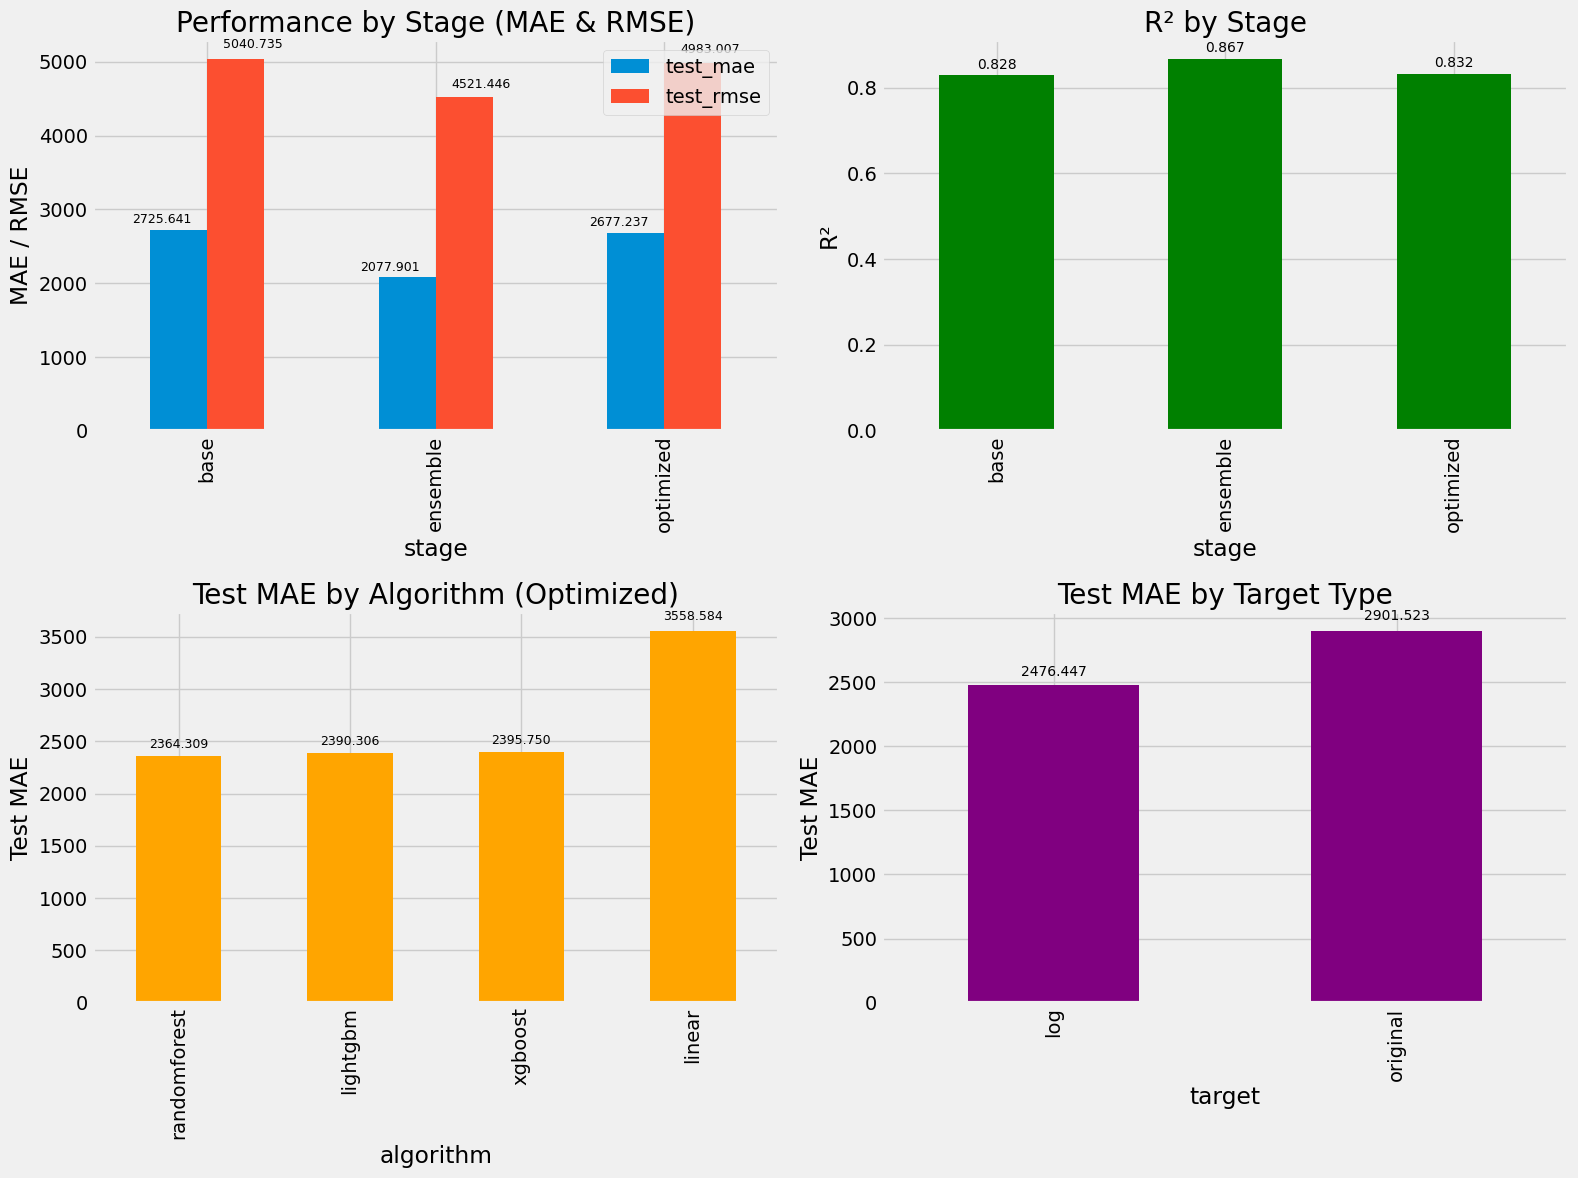


🎯 Pipeline completed! Processed 33 model configurations.
💡 Best improvement with log transform: log target achieved lowest error rates.


In [28]:
# 5. Visualization  
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Compare performance across stages  
stage_perf = final_results.groupby('stage')[['test_mae', 'test_rmse', 'test_r2']].mean()

# MAE & RMSE comparison chart  
bars1 = stage_perf[['test_mae', 'test_rmse']].plot(kind='bar', ax=axes[0,0], title='Performance by Stage (MAE & RMSE)')
axes[0,0].set_ylabel('MAE / RMSE')
axes[0,0].legend()

# Annotate MAE & RMSE values on chart  
for i, stage in enumerate(stage_perf.index):
    mae_val = stage_perf.loc[stage, 'test_mae']
    rmse_val = stage_perf.loc[stage, 'test_rmse']
    axes[0,0].text(i-0.2, mae_val + mae_val*0.02, f'{mae_val:.3f}', ha='center', va='bottom', fontsize=9)
    axes[0,0].text(i+0.2, rmse_val + rmse_val*0.02, f'{rmse_val:.3f}', ha='center', va='bottom', fontsize=9)

# R² comparison chart  
bars2 = stage_perf['test_r2'].plot(kind='bar', ax=axes[0,1], title='R² by Stage', color='green')
axes[0,1].set_ylabel('R²')

# Annotate R² values on chart  
for i, (stage, r2_val) in enumerate(stage_perf['test_r2'].items()):
    axes[0,1].text(i, r2_val + r2_val*0.01, f'{r2_val:.3f}', ha='center', va='bottom', fontsize=10)

# Algorithm-wise performance (for optimized models)  
if len(optimized_results_df) > 0:
    algo_perf = optimized_results_df.groupby('algorithm')['test_mae'].mean().sort_values()
    bars3 = algo_perf.plot(kind='bar', ax=axes[1,0], title='Test MAE by Algorithm (Optimized)', color='orange')
    axes[1,0].set_ylabel('Test MAE')
    
    # Annotate MAE for each algorithm  
    for i, (algo, mae_val) in enumerate(algo_perf.items()):
        axes[1,0].text(i, mae_val + mae_val*0.02, f'{mae_val:.3f}', ha='center', va='bottom', fontsize=9, rotation=0)

# Target transformation-wise performance  
if len(final_results[final_results['target'].notna()]) > 0:
    target_perf = final_results[final_results['target'].notna()].groupby('target')['test_mae'].mean()
    bars4 = target_perf.plot(kind='bar', ax=axes[1,1], title='Test MAE by Target Type', color='purple')
    axes[1,1].set_ylabel('Test MAE')
    
    # Annotate MAE for each target type  
    for i, (target, mae_val) in enumerate(target_perf.items()):
        axes[1,1].text(i, mae_val + mae_val*0.02, f'{mae_val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n🎯 Pipeline completed! Processed {len(final_results)} model configurations.")
print(f"💡 Best improvement with log transform: {best_target_type} target achieved lowest error rates.")

The performance comparison at each stage is visualized as follows.
It is evident that the ensemble model demonstrates the highest performance among all.
Additionally, when comparing the average MAE values of models trained on log-transformed data versus those trained on the original data, the log-transformed models consistently exhibit lower MAE values.
This suggests that log transformation contributed to reducing prediction error to a certain extent.

---

各ステージごとの性能比較を可視化すると、次のようになります。
すべてのモデルの中でアンサンブルモデルが最も高い性能を示していることが明らかになりました。
さらに、ログ変換されたデータで学習したモデルと元のデータで学習したモデルのMAEの平均値を比較すると、ログ変換されたモデルの方が一貫してMAEが低いことが確認できます。
これは、ログ変換が予測誤差の低減に一定の効果をもたらしたことを示唆しています。

## 3-2. Final Predictions vs Real Value Scatter

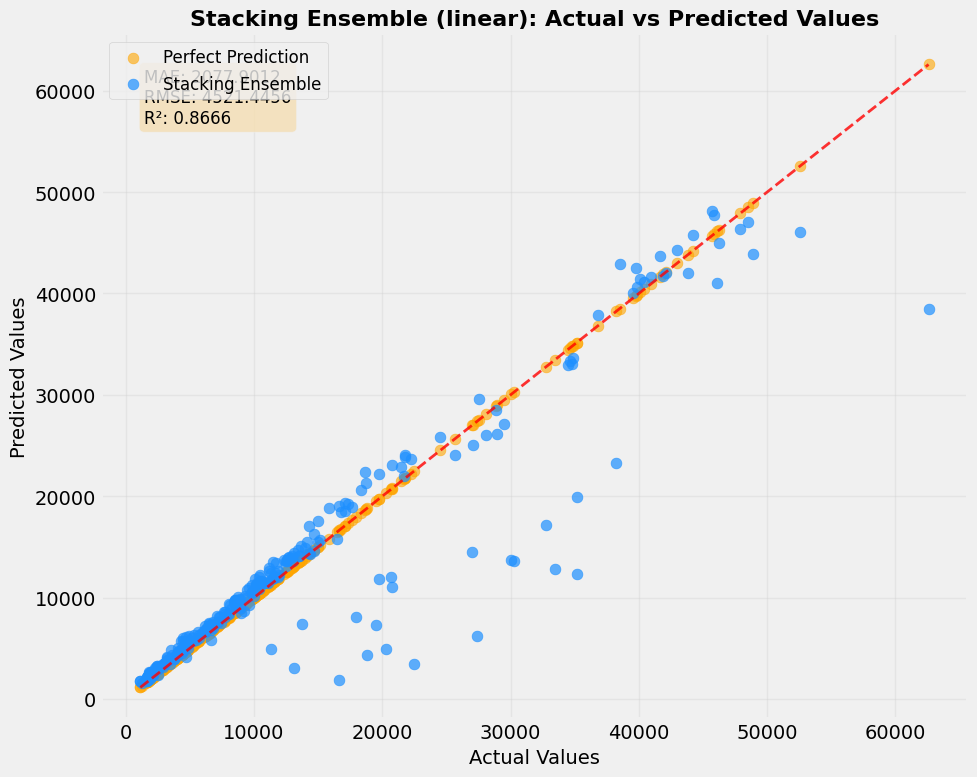


✅ Pipeline completed successfully!

Summary:
- Trained 16 base models
- Optimized 16 models with Optuna
- Created stacking ensemble with 5-fold CV
- Best target type: log
- Best ensemble meta model: linear
- Best single model MAE: 2105.0319
- Stacking ensemble MAE: 2077.9012
- Stacking ensemble RMSE: 4521.4456
- Stacking ensemble R²: 0.8666


In [29]:
# =====================================================================
# 5. Scatter plot of predicted vs actual values from stacking model  
# =====================================================================
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_test, alpha=0.6, color='orange', label='Perfect Prediction', s=60)
plt.scatter(y_test, final_pred, alpha=0.7, color='dodgerblue', label='Stacking Ensemble', s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, alpha=0.8)
plt.xlabel('Actual Values', fontsize=14)
plt.ylabel('Predicted Values', fontsize=14)
plt.title(f'Stacking Ensemble ({best_ensemble_result["meta_name"]}): Actual vs Predicted Values', 
          fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# add metrics 
textstr = f'MAE: {ensemble_mae}\nRMSE: {ensemble_rmse}\nR²: {ensemble_r2}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=props)
plt.tight_layout()
plt.show()

print("\n✅ Pipeline completed successfully!")
print("\nSummary:")
print(f"- Trained {len(base_results_df)} base models")
print(f"- Optimized {len(optimized_results_df)} models with Optuna")
print(f"- Created stacking ensemble with 5-fold CV")
print(f"- Best target type: {best_target_type}")
print(f"- Best ensemble meta model: {best_ensemble_result['meta_name']}")
print(f"- Best single model MAE: {all_results[all_results['stage'] != 'ensemble']['test_mae'].min()}")
print(f"- Stacking ensemble MAE: {ensemble_mae}")
print(f"- Stacking ensemble RMSE: {ensemble_rmse}")
print(f"- Stacking ensemble R²: {ensemble_r2}")

# 전체 결과 통합
final_results = pd.concat([base_results_df, optimized_results_df, ensemble_results_df], ignore_index=True)

The above scatter plot visualizes the relationship between the final model’s predictions and the actual target values.
Although there are a few individual samples where prediction errors are noticeable, the model demonstrates strong overall alignment with the true values, indicating good predictive performance.

---

上記の散布図は、最終モデルによる予測値と実際のターゲット値との関係を示しています。
一部のサンプルでは予測誤差が見られるものの、全体的には実測値に対して良好な一致を示しており、高い予測性能が確認できます。


Thnaks for reading! 

2025/06/18 Nissan Summer internship Theme 5 Assignment

# Improvement 改善点

 1. PCA 次元縮小
 2. Tip from the discussion (数字型変数の取り扱い　・　現実でとコンペでの扱い方)
- https://www.kaggle.com/competitions/playground-series-s5e6/discussion/585000
- https://www.kaggle.com/datasets/mirichoi0218/insurance/discussion/65950

実際のデータでは、数字型をビーニングするが、合成された、仮データでは、数字型データを整数を維持しながら、カテゴリ化することで、性能が上がる可能性がある。

In [30]:
# 0. Import necessary libraries  
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, LabelEncoder
from sklearn.decomposition import PCA
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from xgboost import XGBRegressor
import optuna

# Suppress warnings and logging output  
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.CRITICAL)
print("=" * 80)
print("COMPREHENSIVE ML PIPELINE: Base → Optimized → Ensemble + PCA Enhancement")
print("4 Algorithms × 3 Feature Sets × 2 Target Types × 3 Stages")
print("=" * 80)

COMPREHENSIVE ML PIPELINE: Base → Optimized → Ensemble + PCA Enhancement
4 Algorithms × 3 Feature Sets × 2 Target Types × 3 Stages


In [31]:
# 1. Load the dataset and perform initial train-test split  
df = pd.read_csv('/kaggle/input/insurance/insurance.csv')
seed = 42
target_col = 'charges'

# Apply log transformation and stratified binning for the target variable  
df['charges_log'] = np.log1p(df[target_col])
df['charges_bin'], bins = pd.qcut(df['charges_log'], q=10, labels=False, retbins=True, duplicates='drop')

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['charges_bin'], random_state=seed)
train_df = train_df.drop(columns=['charges_log', 'charges_bin'])
test_df = test_df.drop(columns=['charges_log', 'charges_bin'])
print(f"📊 Dataset: {len(train_df)} train, {len(test_df)} test samples")

print(train_df.head())

📊 Dataset: 1070 train, 268 test samples
      age     sex     bmi  children smoker     region      charges
806    40  female  41.420         1     no  northwest  28476.73499
346    33    male  35.750         2     no  southeast   4889.99950
453    20    male  29.735         0     no  northwest   1769.53165
1134   28    male  33.820         0     no  northwest  19673.33573
220    34  female  33.700         1     no  southwest   5012.47100


In [32]:
# 2. Preprocessing: 요구사항에 맞춘 전처리
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

def preprocess_data(train_df, test_df, target_col='charges'):
    """
    전처리 요구사항:
    1. sex, smoker → 0,1 이진 인코딩
    2. region → 라벨 인코딩
    3. age, children → 라벨 인코딩  
    4. bmi → 소수점 제거 후 라벨 인코딩
    """
    
    # 복사본 생성
    train_processed = train_df.copy()
    test_processed = test_df.copy()
    
    print("🔍 전처리 전 데이터 확인:")
    print("Train 데이터:")
    print(train_processed.head())
    print(f"Train shape: {train_processed.shape}")
    print(f"Train dtypes:\n{train_processed.dtypes}")
    
    # 1. 이진 범주형 변수 처리 (sex, smoker)
    print("\n📝 1. 이진 범주형 변수 처리 (sex, smoker)")
    
    # sex: male=1, female=0
    if 'sex' in train_processed.columns:
        print(f"   sex 고유값: {train_processed['sex'].unique()}")
        train_processed['sex'] = train_processed['sex'].map({'male': 1, 'female': 0})
        test_processed['sex'] = test_processed['sex'].map({'male': 1, 'female': 0})
        print(f"   sex 변환 후: {train_processed['sex'].unique()}")
    
    # smoker: yes=1, no=0  
    if 'smoker' in train_processed.columns:
        print(f"   smoker 고유값: {train_processed['smoker'].unique()}")
        train_processed['smoker'] = train_processed['smoker'].map({'yes': 1, 'no': 0})
        test_processed['smoker'] = test_processed['smoker'].map({'yes': 1, 'no': 0})
        print(f"   smoker 변환 후: {train_processed['smoker'].unique()}")
    
    # 2. BMI 처리 (소수점 제거)
    print("\n📝 2. BMI 소수점 제거")
    if 'bmi' in train_processed.columns:
        print(f"   BMI 원본 예시: {train_processed['bmi'].head().values}")
        train_processed['bmi'] = np.floor(train_processed['bmi']).astype(int)
        test_processed['bmi'] = np.floor(test_processed['bmi']).astype(int)
        print(f"   BMI 변환 후: {train_processed['bmi'].head().values}")
    
    # 3. 라벨 인코딩할 컬럼들
    label_encode_cols = ['region', 'age', 'children', 'bmi']
    
    print("\n📝 3. 라벨 인코딩 수행")
    label_encoders = {}
    
    for col in label_encode_cols:
        if col in train_processed.columns:
            print(f"   {col} 라벨 인코딩...")
            print(f"     원본 고유값 수: {train_processed[col].nunique()}")
            print(f"     원본 예시: {sorted(train_processed[col].unique())[:5]}")
            
            # 라벨 인코더 생성 및 학습
            le = LabelEncoder()
            train_processed[col] = le.fit_transform(train_processed[col])
            
            # 테스트 데이터 변환 (새로운 카테고리 처리)
            test_unique = set(test_processed[col].unique())
            train_unique = set(le.classes_)
            new_categories = test_unique - train_unique
            
            if new_categories:
                print(f"     ⚠️ 테스트에만 있는 새로운 값들: {new_categories}")
                # 새로운 카테고리는 가장 빈번한 값으로 대체
                most_frequent = train_processed[col].mode()[0] if len(train_processed[col].mode()) > 0 else 0
                test_processed[col] = test_processed[col].apply(
                    lambda x: most_frequent if x in new_categories else x
                )
            
            # 알려진 카테고리만 변환
            test_processed[col] = test_processed[col].apply(
                lambda x: x if x in le.classes_ else le.classes_[0]
            )
            test_processed[col] = le.transform(test_processed[col])
            
            # 인코더 저장
            label_encoders[col] = le
            
            print(f"     변환 후 범위: 0 ~ {max(train_processed[col].max(), test_processed[col].max())}")
    
    # 4. 최종 결과 확인
    print("\n📊 전처리 완료!")
    print(f"Train shape: {train_processed.shape}")
    print(f"Test shape: {test_processed.shape}")
    
    print("\n최종 데이터 타입:")
    print(train_processed.dtypes)
    
    print("\n최종 데이터 미리보기:")
    print(train_processed.head())
    
    # 피처와 타겟 분리
    feature_cols = [col for col in train_processed.columns if col != target_col]
    
    X_train = train_processed[feature_cols]
    y_train = train_processed[target_col] if target_col in train_processed.columns else None
    
    X_test = test_processed[feature_cols] 
    y_test = test_processed[target_col] if target_col in test_processed.columns else None
    
    print(f"\n📈 최종 피처 차원: {X_train.shape}")
    print(f"피처 목록: {list(X_train.columns)}")
    
    return {
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test, 
        'y_test': y_test,
        'label_encoders': label_encoders,
        'train_processed': train_processed,
        'test_processed': test_processed
    }

def create_three_feature_sets(train_df, test_df, target_col='charges'):
    """
    3가지 피처 세트 생성:
    1. basic: 기본 전처리 (위에서 만든 것)
    2. encoded: 추가 피처 엔지니어링 
    3. pca: PCA 차원 축소
    """
    from sklearn.preprocessing import StandardScaler, PolynomialFeatures
    from sklearn.decomposition import PCA
    
    # 1. 기본 전처리 수행
    print("🔧 1단계: 기본 전처리 수행")
    basic_results = preprocess_data(train_df, test_df, target_col)
    
    X_train_basic = basic_results['X_train']
    X_test_basic = basic_results['X_test'] 
    y_train = basic_results['y_train']
    y_test = basic_results['y_test']
    
    print(f"   Basic 피처 세트: {X_train_basic.shape}")
    
    # 2. Encoded 피처 세트 (모든 수치형 변수를 정수로 변환 후 라벨 인코딩)
    print("\n🔧 2단계: Encoded 피처 세트 생성")
    
    # 기본 피처 복사
    X_train_encoded = X_train_basic.copy()
    X_test_encoded = X_test_basic.copy()
    
    # age, children은 이미 정수이지만 라벨 인코딩 적용
    # bmi는 이미 floor 처리되어 정수화됨
    
    # age를 라벨 인코딩 (ordinal 없이 categorical로 처리)
    from sklearn.preprocessing import LabelEncoder
    age_encoder = LabelEncoder()
    X_train_encoded['age'] = age_encoder.fit_transform(X_train_encoded['age'].astype(str))
    
    # 테스트에서 새로운 나이가 있을 수 있으므로 안전하게 처리
    test_ages = X_test_encoded['age'].astype(str)
    known_ages = age_encoder.classes_
    test_ages = test_ages.apply(lambda x: x if x in known_ages else known_ages[0])
    X_test_encoded['age'] = age_encoder.transform(test_ages)
    
    # children을 라벨 인코딩
    children_encoder = LabelEncoder()
    X_train_encoded['children'] = children_encoder.fit_transform(X_train_encoded['children'].astype(str))
    
    test_children = X_test_encoded['children'].astype(str)
    known_children = children_encoder.classes_
    test_children = test_children.apply(lambda x: x if x in known_children else known_children[0])
    X_test_encoded['children'] = children_encoder.transform(test_children)
    
    # bmi를 라벨 인코딩 (이미 정수화됨)
    bmi_encoder = LabelEncoder()
    X_train_encoded['bmi'] = bmi_encoder.fit_transform(X_train_encoded['bmi'].astype(str))
    
    test_bmi = X_test_encoded['bmi'].astype(str)
    known_bmi = bmi_encoder.classes_
    test_bmi = test_bmi.apply(lambda x: x if x in known_bmi else known_bmi[0])
    X_test_encoded['bmi'] = bmi_encoder.transform(test_bmi)
    
    print(f"   Encoded 피처 세트: {X_train_encoded.shape}")
    print(f"   라벨 인코딩 적용된 변수: age, children, bmi")
    print(f"   age 라벨 수: {len(age_encoder.classes_)}")
    print(f"   children 라벨 수: {len(children_encoder.classes_)}")
    print(f"   bmi 라벨 수: {len(bmi_encoder.classes_)}")
    
    # 3. PCA 피처 세트
    print("\n🔧 3단계: PCA 피처 세트 생성")
    
    # 표준화
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_encoded)
    X_test_scaled = scaler.transform(X_test_encoded)
    
    # 다항식 피처 생성 (2차)
    poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)
    
    print(f"   다항식 피처 생성 후: {X_train_poly.shape}")
    
    # PCA 적용 (95% 분산 유지)
    pca = PCA(n_components=0.95, random_state=42)
    X_train_pca_array = pca.fit_transform(X_train_poly)
    X_test_pca_array = pca.transform(X_test_poly)
    
    # PCA 결과를 DataFrame으로 변환
    pca_columns = [f'pca_component_{i}' for i in range(X_train_pca_array.shape[1])]
    X_train_pca = pd.DataFrame(X_train_pca_array, 
                              columns=pca_columns, 
                              index=X_train_basic.index)
    X_test_pca = pd.DataFrame(X_test_pca_array, 
                             columns=pca_columns, 
                             index=X_test_basic.index)
    
    print(f"   PCA 피처 세트: {X_train_pca.shape}")
    print(f"   PCA 누적 설명 분산비: {pca.explained_variance_ratio_.sum():.3f}")
    
    # 최종 결과 요약
    print(f"\n📊 최종 피처 세트 요약:")
    print(f"   1. Basic: {X_train_basic.shape}")
    print(f"   2. Encoded: {X_train_encoded.shape}")  
    print(f"   3. PCA: {X_train_pca.shape}")
    
    return {
        'train_basic': X_train_basic,
        'train_encoded': X_train_encoded,
        'train_pca': X_train_pca,
        'test_basic': X_test_basic,
        'test_encoded': X_test_encoded, 
        'test_pca': X_test_pca,
        'y_train': y_train,
        'y_test': y_test,
        'transformers': {
            'scaler': scaler,
            'poly': poly, 
            'pca': pca
        }
    }

# 실행 - 3가지 피처 세트 생성
print("🚀 3가지 피처 세트 생성 시작...")
results = create_three_feature_sets(train_df, test_df, target_col='charges')

# 변수명 매칭
X_train_basic = results['train_basic']
X_train_encoded = results['train_encoded'] 
X_train_pca = results['train_pca']
X_test_basic = results['test_basic']
X_test_encoded = results['test_encoded']
X_test_pca = results['test_pca']
y_train = results['y_train']
y_test = results['y_test']

print(f"\n✅ 3가지 피처 세트 생성 완료!")
print(f"   X_train_basic: {X_train_basic.shape}")
print(f"   X_train_encoded: {X_train_encoded.shape}")
print(f"   X_train_pca: {X_train_pca.shape}")

# 로그 변환된 타겟도 준비
if y_train is not None:
    y_train_log = np.log1p(y_train)
    y_test_log = np.log1p(y_test) if y_test is not None else None
    print(f"   로그 변환된 타겟도 준비 완료!")

🚀 3가지 피처 세트 생성 시작...
🔧 1단계: 기본 전처리 수행
🔍 전처리 전 데이터 확인:
Train 데이터:
      age     sex     bmi  children smoker     region      charges
806    40  female  41.420         1     no  northwest  28476.73499
346    33    male  35.750         2     no  southeast   4889.99950
453    20    male  29.735         0     no  northwest   1769.53165
1134   28    male  33.820         0     no  northwest  19673.33573
220    34  female  33.700         1     no  southwest   5012.47100
Train shape: (1070, 7)
Train dtypes:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

📝 1. 이진 범주형 변수 처리 (sex, smoker)
   sex 고유값: ['female' 'male']
   sex 변환 후: [0 1]
   smoker 고유값: ['no' 'yes']
   smoker 변환 후: [0 1]

📝 2. BMI 소수점 제거
   BMI 원본 예시: [41.42  35.75  29.735 33.82  33.7  ]
   BMI 변환 후: [41 35 29 33 33]

📝 3. 라벨 인코딩 수행
   region 라벨 인코딩...
     원본 고유값 수: 4
     원본 예시: ['northeast', 'northwest', 'southeast', 'southw

In [33]:
# 전처리 결과 변수들을 기반으로 구성 설정
features = {
    'basic': (X_train_basic, X_test_basic),
    'encoded': (X_train_encoded, X_test_encoded),  # label_encoded -> encoded로 변경
    'pca': (X_train_pca, X_test_pca)  # pca_enhanced -> pca로 변경
}

targets = {
    'original': (y_train, y_test, False),
    'log': (y_train_log, y_test_log, True)
}

models_config = {
    'linear': LinearRegression(),
    'lightgbm': LGBMRegressor(
        learning_rate=0.05, n_estimators=200, num_leaves=31, max_depth=7,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=0.1, random_state=42, verbosity=-1
    ),
    'xgboost': XGBRegressor(
        learning_rate=0.05, n_estimators=200, max_depth=7, min_child_weight=20,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
        random_state=42, verbosity=0
    ),
    'randomforest': RandomForestRegressor(
        n_estimators=200, max_depth=10, min_samples_split=20, min_samples_leaf=10,
        max_features=0.8, random_state=42, n_jobs=-1
    )
}

In [34]:
# =====================================================================
# STAGE 1: Baseline model performance comparison  
# =====================================================================
print("\n🔄 STAGE 1: Training base models...")

def train_and_evaluate_model(model, model_name, X_tr, X_te, y_tr, y_te, is_log_target=False):
    """모델 훈련 및 평가 함수"""
    X_tr_sub, X_cv_sub, y_tr_sub, y_cv_sub = train_test_split(
        X_tr, y_tr, test_size=0.2, random_state=42
    )
    
    # Model Training
    if model_name == 'lightgbm':
        model.fit(X_tr_sub, y_tr_sub, eval_set=[(X_cv_sub, y_cv_sub)],
                 callbacks=[early_stopping(stopping_rounds=20), log_evaluation(period=0)])
    elif model_name == 'xgboost':
        model.fit(X_tr_sub, y_tr_sub, eval_set=[(X_cv_sub, y_cv_sub)],
                 early_stopping_rounds=20, verbose=False)
    else:
        model.fit(X_tr_sub, y_tr_sub)
    
    # Prediction
    pred_train = model.predict(X_tr_sub)
    pred_cv = model.predict(X_cv_sub)
    pred_test = model.predict(X_te)
    
    # Apply inverse log transformation
    if is_log_target:
        pred_train = np.expm1(pred_train)
        pred_cv = np.expm1(pred_cv)
        pred_test = np.expm1(pred_test)
        y_tr_eval = np.expm1(y_tr_sub)
        y_cv_eval = np.expm1(y_cv_sub)
        y_te_eval = np.expm1(y_te)
    else:
        y_tr_eval = y_tr_sub
        y_cv_eval = y_cv_sub
        y_te_eval = y_te
    
    return {
        'train_rmse': round(mean_squared_error(y_tr_eval, pred_train, squared=False), 4),
        'train_mae': round(mean_absolute_error(y_tr_eval, pred_train), 4),
        'train_r2': round(r2_score(y_tr_eval, pred_train), 4),
        'cv_rmse': round(mean_squared_error(y_cv_eval, pred_cv, squared=False), 4),
        'cv_mae': round(mean_absolute_error(y_cv_eval, pred_cv), 4),
        'cv_r2': round(r2_score(y_cv_eval, pred_cv), 4),
        'test_rmse': round(mean_squared_error(y_te_eval, pred_test, squared=False), 4),
        'test_mae': round(mean_absolute_error(y_te_eval, pred_test), 4),
        'test_r2': round(r2_score(y_te_eval, pred_test), 4)
    }

base_results = []
for model_name, model in models_config.items():
    for feat_name, (X_tr, X_te) in features.items():
        for target_name, (y_tr, y_te, is_log) in targets.items():
            print(f"  🔄 Training {model_name}_{feat_name}_{target_name}...")
            metrics = train_and_evaluate_model(model, model_name, X_tr, X_te, y_tr, y_te, is_log)
            metrics.update({
                'model': f'{model_name}_{feat_name}_{target_name}',
                'algorithm': model_name,
                'features': feat_name,
                'target': target_name,
                'stage': 'base'
            })
            base_results.append(metrics)

base_results_df = pd.DataFrame(base_results)
print("✅ Base models completed!")
print(base_results_df.head(10))


🔄 STAGE 1: Training base models...
  🔄 Training linear_basic_original...
  🔄 Training linear_basic_log...
  🔄 Training linear_encoded_original...
  🔄 Training linear_encoded_log...
  🔄 Training linear_pca_original...
  🔄 Training linear_pca_log...
  🔄 Training lightgbm_basic_original...
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[119]	valid_0's l2: 1.61329e+07
  🔄 Training lightgbm_basic_log...
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[104]	valid_0's l2: 0.114698
  🔄 Training lightgbm_encoded_original...
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[109]	valid_0's l2: 1.76844e+07
  🔄 Training lightgbm_encoded_log...
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[150]	valid_0's l2: 0.131423
  🔄 Training lightgbm_pca_original...
Training until validation scores don't improve for 20

In [35]:
# =====================================================================
# STAGE 2: Optuna Hyperparameter Optimization  
# =====================================================================
print("\n🔍 STAGE 2: Hyperparameter optimization with Optuna...")

def create_objective(model_name, X_train, y_train, is_log_target=False):
    def objective(trial):
        X_tr_sub, X_val_sub, y_tr_sub, y_val_sub = train_test_split(
            X_train, y_train, test_size=0.2, random_state=42
        )
        
        if model_name == 'lightgbm':
            params = {
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'n_estimators': 1000,
                'num_leaves': trial.suggest_int('num_leaves', 16, 128),
                'max_depth': trial.suggest_int('max_depth', 3, 12),
                'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
                'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
                'random_state': 42, 'verbosity': -1
            }
            model = LGBMRegressor(**params)
            model.fit(X_tr_sub, y_tr_sub, eval_set=[(X_val_sub, y_val_sub)],
                     callbacks=[early_stopping(15), log_evaluation(period=0)])
                     
        elif model_name == 'xgboost':
            params = {
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'n_estimators': 1000,
                'max_depth': trial.suggest_int('max_depth', 3, 12),
                'min_child_weight': trial.suggest_int('min_child_weight', 5, 50),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
                'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
                'random_state': 42, 'verbosity': 0
            }
            model = XGBRegressor(**params)
            model.fit(X_tr_sub, y_tr_sub, eval_set=[(X_val_sub, y_val_sub)],
                     early_stopping_rounds=15, verbose=False)
                     
        elif model_name == 'randomforest':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 300),
                'max_depth': trial.suggest_int('max_depth', 5, 15),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
                'max_features': trial.suggest_float('max_features', 0.3, 1.0),
                'random_state': 42, 'n_jobs': -1
            }
            model = RandomForestRegressor(**params)
            model.fit(X_tr_sub, y_tr_sub)
        
        preds = model.predict(X_val_sub)
        
        # Evaluate after restoring log-transformed predictions  
        if is_log_target:
            preds = np.expm1(preds)
            y_val_eval = np.expm1(y_val_sub)
        else:
            y_val_eval = y_val_sub
            
        return mean_squared_error(y_val_eval, preds, squared=False)
    
    return objective

# Run optimization  
optimized_results = []
best_params_storage = {}

for model_name in ['lightgbm', 'xgboost', 'randomforest']:
    for feat_name, (X_tr, X_te) in features.items():
        for target_name, (y_tr, y_te, is_log) in targets.items():
            print(f"  ⚡ Optimizing {model_name}_{feat_name}_{target_name}...")
            
            # Optuna 
            study = optuna.create_study(direction='minimize', 
                                      sampler=optuna.samplers.TPESampler(seed=42))
            study.optimize(create_objective(model_name, X_tr, y_tr, is_log), 
                          n_trials=50, show_progress_bar=False)
            
            # hyperparameter tuning
            key = f'{model_name}_{feat_name}_{target_name}'
            best_params_storage[key] = study.best_trial.params
            
            # save best parameters
            best_params = study.best_trial.params.copy()
            
            if model_name == 'lightgbm':
                best_params.update({'n_estimators': 1000, 'random_state': 42, 'verbosity': -1})
                model = LGBMRegressor(**best_params)
            elif model_name == 'xgboost':
                best_params.update({'n_estimators': 1000, 'random_state': 42, 'verbosity': 0})
                model = XGBRegressor(**best_params)
            elif model_name == 'randomforest':
                best_params.update({'random_state': 42, 'n_jobs': -1})
                model = RandomForestRegressor(**best_params)
            
            metrics = train_and_evaluate_model(model, model_name, X_tr, X_te, y_tr, y_te, is_log)
            metrics.update({
                'model': f'{model_name}_opt_{feat_name}_{target_name}',
                'algorithm': model_name,
                'features': feat_name,
                'target': target_name,
                'stage': 'optimized'
            })
            optimized_results.append(metrics)

# Linear model
for feat_name, (X_tr, X_te) in features.items():
    for target_name, (y_tr, y_te, is_log) in targets.items():
        model = LinearRegression()
        metrics = train_and_evaluate_model(model, 'linear', X_tr, X_te, y_tr, y_te, is_log)
        metrics.update({
            'model': f'linear_opt_{feat_name}_{target_name}',
            'algorithm': 'linear',
            'features': feat_name,
            'target': target_name,
            'stage': 'optimized'
        })
        optimized_results.append(metrics)

optimized_results_df = pd.DataFrame(optimized_results)
print("✅ Hyperparameter optimization completed!")
print(optimized_results_df.head(10))


🔍 STAGE 2: Hyperparameter optimization with Optuna...
  ⚡ Optimizing lightgbm_basic_original...
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[185]	valid_0's l2: 1.76418e+07
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[90]	valid_0's l2: 1.55867e+07
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[339]	valid_0's l2: 1.77902e+07
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[185]	valid_0's l2: 1.63734e+07
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[830]	valid_0's l2: 1.57666e+07
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[298]	valid_0's l2: 1.53776e+07
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[55]	valid_0's l2: 1.57353e+07
Training 

In [36]:
# =====================================================================
# STAGE 3: Stacking Ensemble (using best-performing target type)  
# =====================================================================
print("\n🔗 STAGE 3: Building Advanced Stacking Ensemble...")

# Select the best-performing target transformation  
all_results = pd.concat([base_results_df, optimized_results_df])
best_target_type = all_results.groupby('target')['test_mae'].mean().idxmin()
print(f"📊 Using '{best_target_type}' target type for ensemble (lowest avg MAE)")

# Apply the selected target transformation  
y_ensemble_train, y_ensemble_test, is_log_ensemble = targets[best_target_type]

# Set up 5-Fold Cross Validation  
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store OOF predictions and test predictions  
oof_predictions = {}
test_predictions = {}

ensemble_models = ['lightgbm', 'xgboost', 'randomforest', 'linear']

for model_name in ensemble_models:
    for feat_name, (X_tr, X_te) in features.items():
        model_key = f'{model_name}_{feat_name}'
        oof_pred = np.zeros(len(X_tr))
        test_fold_preds = []
        
        print(f"  🔄 Processing {model_key} for ensemble...")
        
        # 인덱스 리셋으로 위치 기반 인덱싱 보장
        X_tr_reset = X_tr.reset_index(drop=True)
        y_ensemble_train_reset = pd.Series(y_ensemble_train).reset_index(drop=True)
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X_tr_reset)):
            X_fold_train = X_tr_reset.iloc[train_idx]
            X_fold_val = X_tr_reset.iloc[val_idx]
            y_fold_train = y_ensemble_train_reset.iloc[train_idx]
            y_fold_val = y_ensemble_train_reset.iloc[val_idx]
            
            # Train base models
            if model_name == 'linear':
                model = LinearRegression()
                model.fit(X_fold_train, y_fold_train)
                
            elif model_name in ['lightgbm', 'xgboost', 'randomforest']:
                # Use optimized parameters
                param_key = f'{model_name}_{feat_name}_{best_target_type}'
                if param_key in best_params_storage:
                    best_params = best_params_storage[param_key].copy()
                else:
                    best_params = {}
                
                if model_name == 'lightgbm':
                    best_params.update({'n_estimators': 1000, 'random_state': 42, 'verbosity': -1})
                    model = LGBMRegressor(**best_params)
                    model.fit(X_fold_train, y_fold_train, eval_set=[(X_fold_val, y_fold_val)],
                             callbacks=[early_stopping(15), log_evaluation(period=0)])
                             
                elif model_name == 'xgboost':
                    best_params.update({'n_estimators': 1000, 'random_state': 42, 'verbosity': 0})
                    model = XGBRegressor(**best_params)
                    model.fit(X_fold_train, y_fold_train, eval_set=[(X_fold_val, y_fold_val)],
                             early_stopping_rounds=15, verbose=False)
                             
                elif model_name == 'randomforest':
                    best_params.update({'random_state': 42, 'n_jobs': -1})
                    model = RandomForestRegressor(**best_params)
                    model.fit(X_fold_train, y_fold_train)
            
            # OOF predictions
            oof_pred[val_idx] = model.predict(X_fold_val)
            # test predictions
            test_fold_preds.append(model.predict(X_te))
        
        oof_predictions[model_key] = oof_pred
        test_predictions[model_key] = np.mean(test_fold_preds, axis=0)

# Train the meta-model
oof_df = pd.DataFrame(oof_predictions)
test_pred_df = pd.DataFrame(test_predictions)

# meta-model
meta_models = {
    'linear': LinearRegression()
}

ensemble_results = []
best_ensemble_result = None
best_ensemble_mae = float('inf')

for meta_name, meta_model in meta_models.items():
    meta_model.fit(oof_df, y_ensemble_train)
    
    # OOF predictions
    oof_meta_pred = meta_model.predict(oof_df)
    # final predictions
    final_pred = meta_model.predict(test_pred_df)
    
    # inverse log transformation
    if is_log_ensemble:
        oof_meta_pred = np.expm1(oof_meta_pred)
        final_pred = np.expm1(final_pred)
        y_train_eval = np.expm1(y_ensemble_train)
        y_test_eval = np.expm1(y_ensemble_test)
    else:
        y_train_eval = y_ensemble_train
        y_test_eval = y_ensemble_test
    
    # performance metrics
    train_mae = round(mean_absolute_error(y_train_eval, oof_meta_pred), 4)
    train_rmse = round(mean_squared_error(y_train_eval, oof_meta_pred, squared=False), 4)
    train_r2 = round(r2_score(y_train_eval, oof_meta_pred), 4)
    
    test_mae = round(mean_absolute_error(y_test_eval, final_pred), 4)
    test_rmse = round(mean_squared_error(y_test_eval, final_pred, squared=False), 4)
    test_r2 = round(r2_score(y_test_eval, final_pred), 4)
    
    # save best-performing ensemble predictions
    if test_mae < best_ensemble_mae:
        best_ensemble_mae = test_mae
        best_ensemble_result = {
            'y_test': y_test_eval,
            'final_pred': final_pred,
            'ensemble_mae': test_mae,
            'ensemble_rmse': test_rmse,
            'ensemble_r2': test_r2,
            'meta_name': meta_name
        }
    
    ensemble_results.append({
        'model': f'stacking_ensemble_{meta_name}',
        'algorithm': 'ensemble',
        'features': 'combined',
        'target': best_target_type,
        'stage': 'ensemble',
        'train_mae': train_mae,
        'train_rmse': train_rmse,
        'train_r2': train_r2,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_r2': test_r2
    })

ensemble_results_df = pd.DataFrame(ensemble_results)
print("✅ Stacking ensemble completed!")
print(ensemble_results_df)


🔗 STAGE 3: Building Advanced Stacking Ensemble...
📊 Using 'log' target type for ensemble (lowest avg MAE)
  🔄 Processing lightgbm_basic for ensemble...
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[220]	valid_0's l2: 0.105138
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[213]	valid_0's l2: 0.136431
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[185]	valid_0's l2: 0.137183
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[124]	valid_0's l2: 0.176135
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[222]	valid_0's l2: 0.168133
  🔄 Processing lightgbm_encoded for ensemble...
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[34]	valid_0's l2: 0.118003
Training until validation scores don't improve for

## Result

In [37]:
# =====================================================================
# Final performance analysis and result output  
# =====================================================================
print("\n" + "="*80)
print("📊 COMPREHENSIVE RESULTS ANALYSIS")
print("="*80)

# Combine all results  
final_results = pd.concat([base_results_df, optimized_results_df, ensemble_results_df], ignore_index=True)

# 1. Best performance per stage  
print("\n🏆 BEST PERFORMANCE BY STAGE:")
stage_best = final_results.loc[final_results.groupby('stage')['test_mae'].idxmin()]
for _, row in stage_best.iterrows():
    print(f"{row['stage'].upper():>12}: {row['model']} (MAE: {row['test_mae']}, R²: {row['test_r2']})")



📊 COMPREHENSIVE RESULTS ANALYSIS

🏆 BEST PERFORMANCE BY STAGE:
        BASE: randomforest_basic_log (MAE: 2161.1672, R²: 0.8631)
    ENSEMBLE: stacking_ensemble_linear (MAE: 1989.5635, R²: 0.8686)
   OPTIMIZED: randomforest_opt_basic_log (MAE: 2129.0251, R²: 0.865)


In [38]:
# 2. Overall best model performance  
overall_best = final_results.loc[final_results['test_mae'].idxmin()]
print(f"\n🥇 OVERALL BEST: {overall_best['model']}")
print(f"   Test MAE:  {overall_best['test_mae']}")
print(f"   Test RMSE: {overall_best['test_rmse']}")
print(f"   Test R²:   {overall_best['test_r2']}")



🥇 OVERALL BEST: stacking_ensemble_linear
   Test MAE:  1989.5635
   Test RMSE: 4487.5133
   Test R²:   0.8686
